In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/shared_helper_modules'))

# General imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
import pickle

warnings.filterwarnings(
    "ignore",
    message="use_inf_as_na option is deprecated",
    category=FutureWarning,
    module="seaborn")

warnings.filterwarnings(
    "ignore",
    message=r"invalid value encountered in log10",
    category=RuntimeWarning,
    module=r".*specparam.*",
)


# NeuroDSP and FOOOF modules
from neurodsp import spectral

from specparam import Bands


# Custom modules

from spk_feat_cluster_analysis import *

from spe1_plotting import *
from spikeparam.patch.fit import Spike

from config import NPX_CHANNELS, CELL_IDS, DICT_PATCH_FS, DICT_CHAN_PRED, DICT_SPK_THRESH, FILTER_SETTINGS


In [3]:
cell_num =1 #MODIFY THIS WHEN RUNNING DIFFERENT CELLS 

npx_fs = 30000 # sampling rate
lfp_fs = 2500 # sampling rate

patch_fs = DICT_PATCH_FS[cell_num ]
spk_thresh = DICT_SPK_THRESH[cell_num]

npx_channels = NPX_CHANNELS
npx_patch_channel = DICT_CHAN_PRED[cell_num ]

### Loading spe-1 data:

I moved the data loading steps to a separate Jupyter Notebook (spe-1_load_data)




## Cell 1  
### Analyze Gamma LFP and whole patch clamp AP relationship for cell 1

## Step 0: Get loaded data 

In [4]:
lfp_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings/c1_lfp.npy'
patch_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c1_patch.npy'


In [5]:
#get cell number 
cell_num = lfp_dir.split('/')[len(lfp_dir.split('/'))-1].split('_')[0]

#get LFP data
lfp_filt = np.load(lfp_dir)
lfp_one_ms = float(lfp_fs / 1000)
lfp_times = np.arange(0, np.shape(lfp_filt)[0]) / lfp_one_ms # in ms instead of sec

#get patch data 
patch_filt = np.load(patch_dir)
patch_one_ms = float(patch_fs  / 1000)
patch_times = np.arange(0, np.shape(patch_filt )[0]) / patch_one_ms # in ms instead of sec

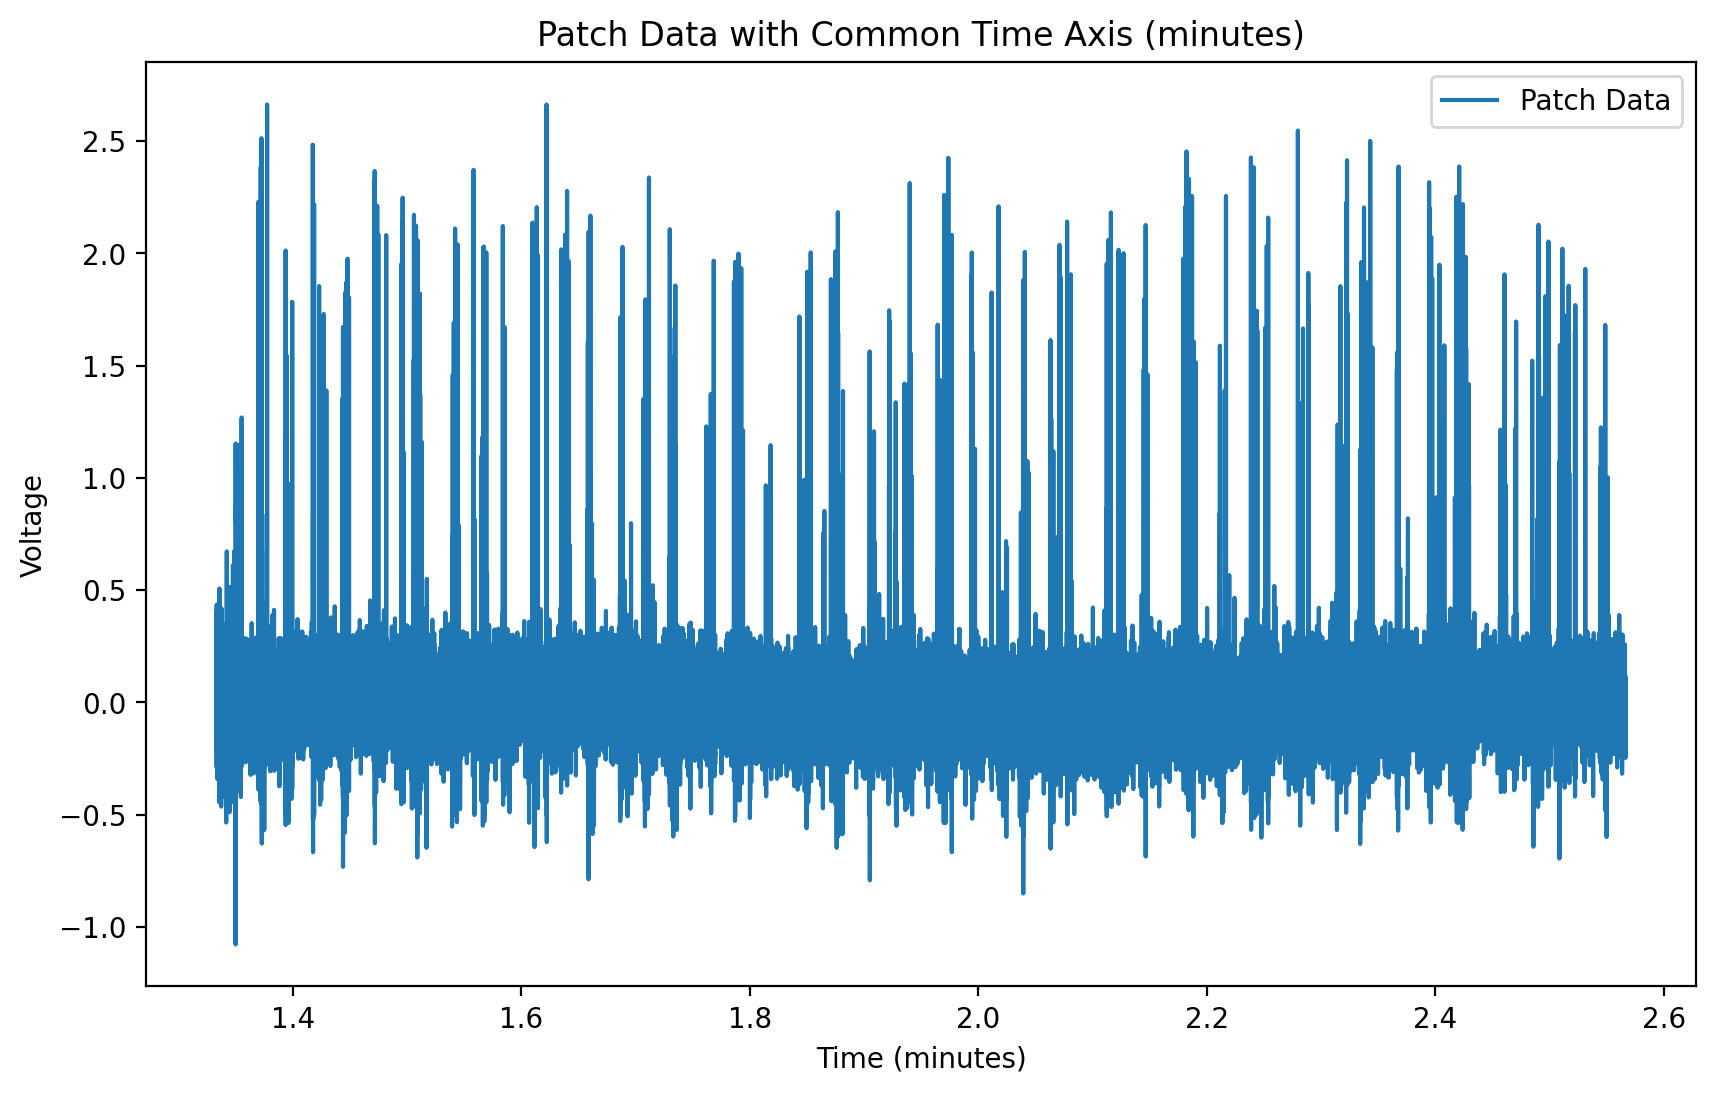

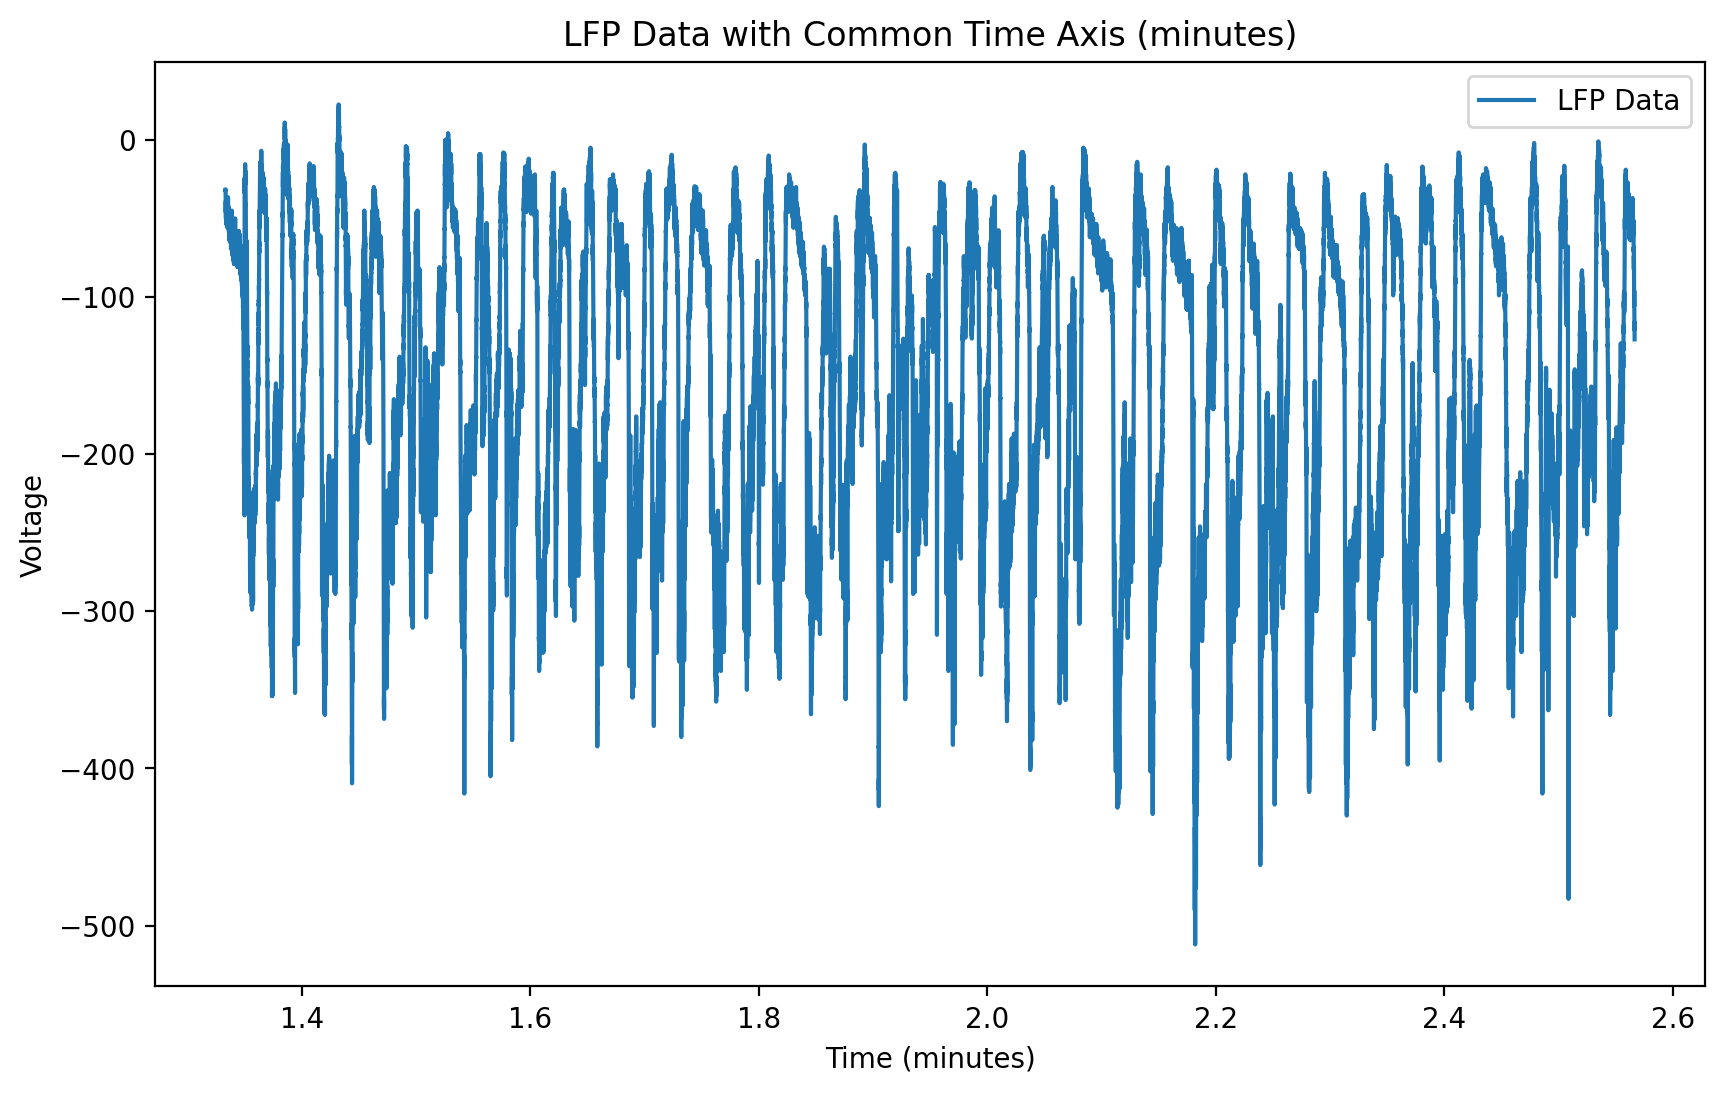

In [6]:
# Plot simultaneous patch and LFP data
# Convert time arrays to minutes
patch_times_min = patch_times / 60000  # Convert milliseconds to minutes
lfp_times_min = lfp_times / 60000  # Convert milliseconds to minutes

# Set the common time axis in minutes (e.g., from 13.3333 to 25.6667 minutes)
common_time_range_min = np.arange(80000 / 60000, 154000 / 60000, 1 / 60000)  # Adjust as needed

# Interpolate patch data onto the common time axis
patch_interp = np.interp(common_time_range_min, patch_times_min, patch_filt)

# Interpolate LFP data onto the common time axis
lfp_interp = np.interp(common_time_range_min, lfp_times_min, lfp_filt)

# Plot patch data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, patch_interp, label='Patch Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('Patch Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

# Plot LFP data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, lfp_interp, label='LFP Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('LFP Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

## STEP 1: Detect and fit spikes from patch data

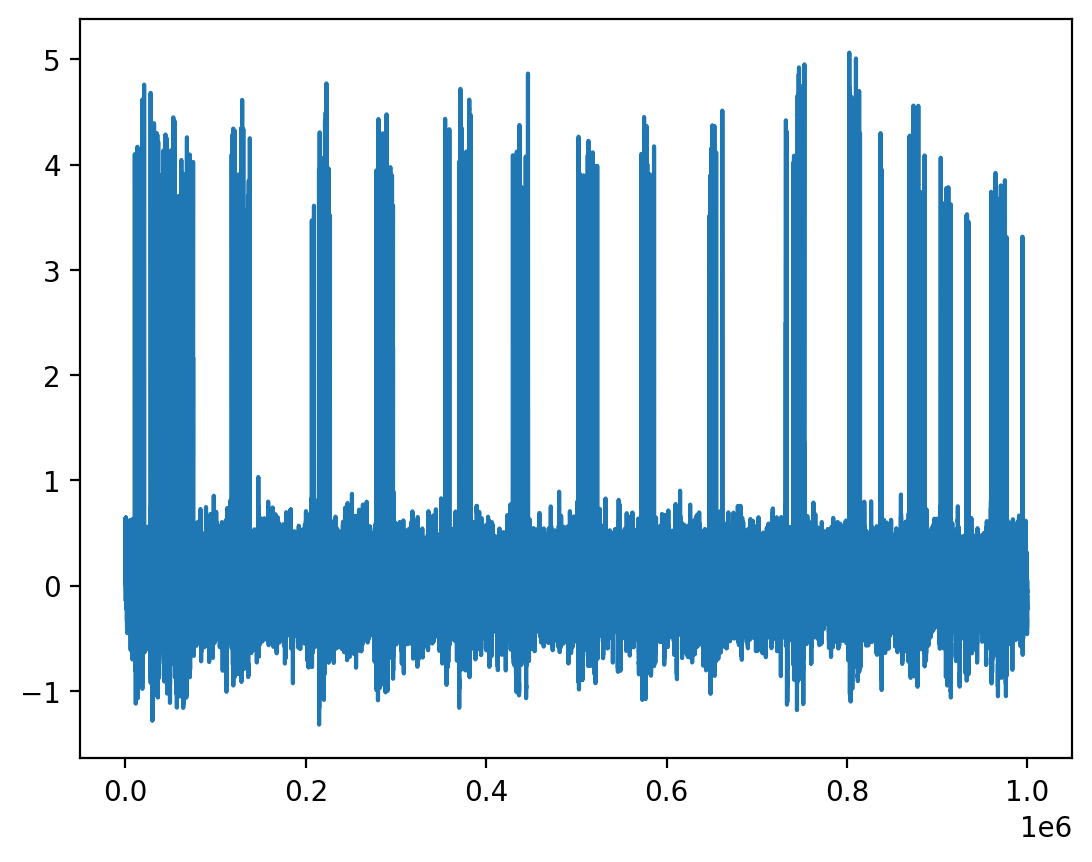

In [7]:
plt.plot(patch_filt[:1000000] )

In [8]:



#threshold in mVs
sp = Spike(thresh_amp=2, window_length=(5., 5.), smooth_frac=.01)

In [9]:

sp.fit(patch_filt, patch_fs, n_jobs=-1, progress=tqdm, flip_signal=False)

Spike:   0%|          | 0/1121 [00:00<?, ?it/s]

/Users/blancamartin/opt/anaconda3/envs/spikeparam/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/blancamartin/opt/anaconda3/envs/spikeparam/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


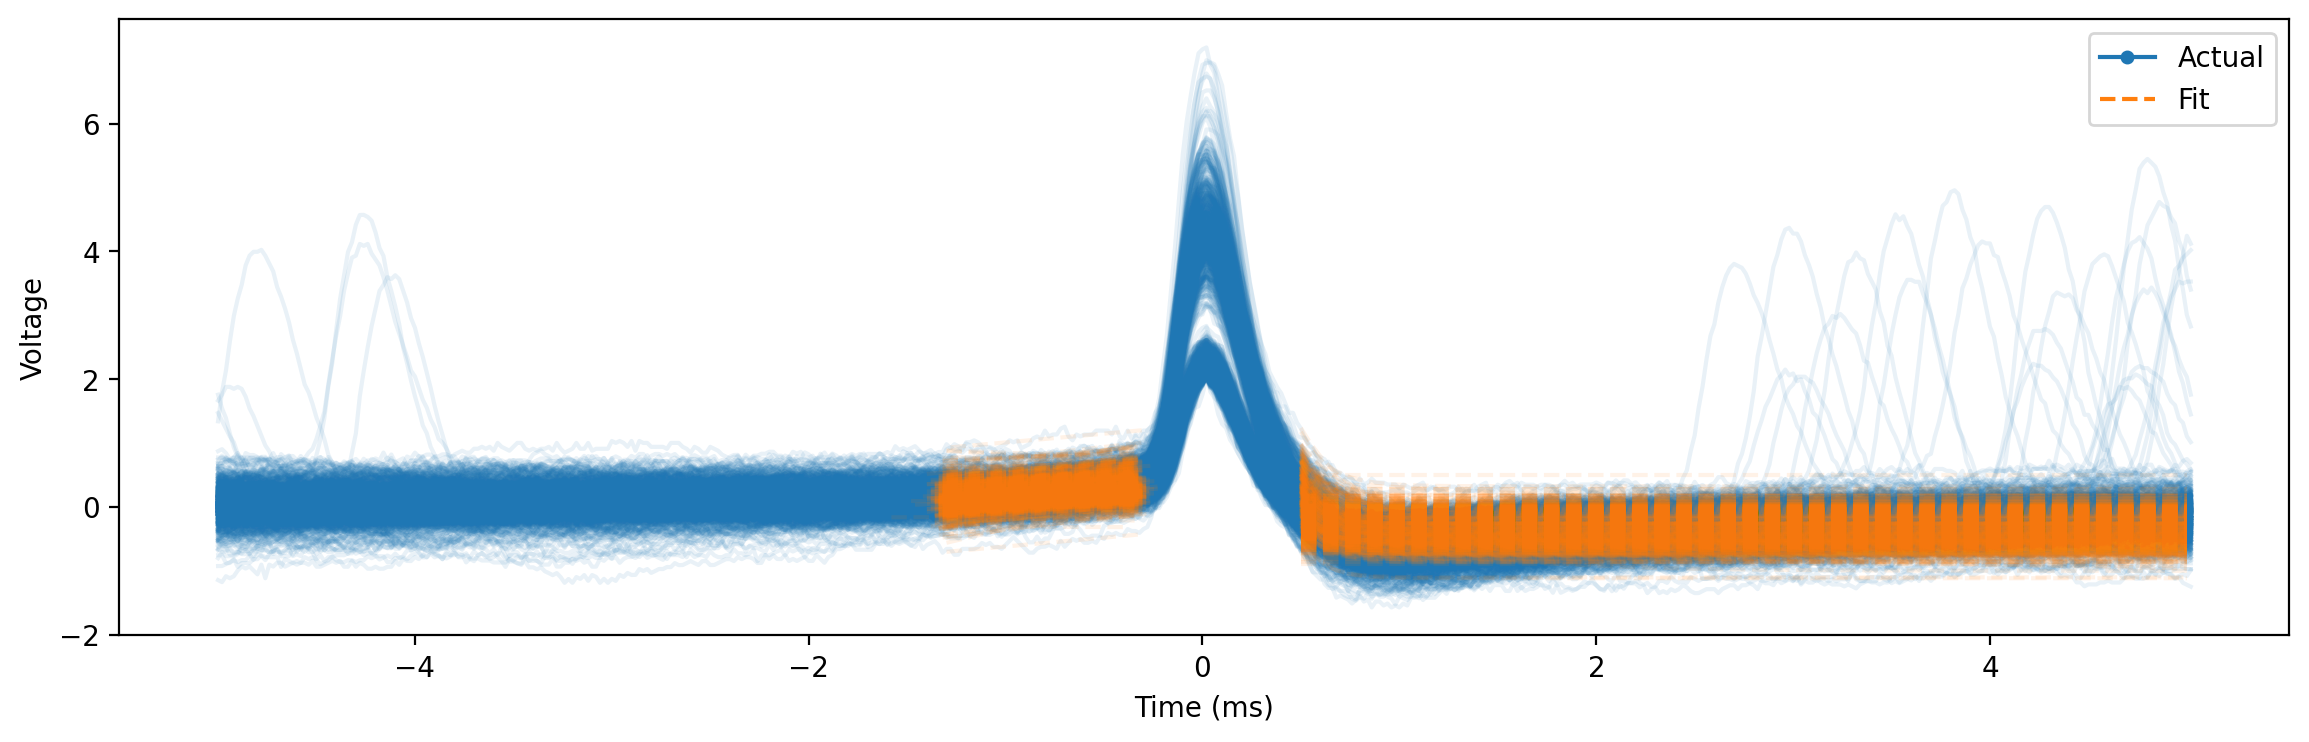

In [10]:
sp.plot()

### Filter spikes 

In [11]:
sp.filter_features()  

### Get spike dataframe (with spike times column)

In [12]:

df_features = sp.df_features

#add columns for spike times, both in idx and ms
df_features['spk_times_idx'] = sp.spike_inds
df_features['spk_times_ms'] = patch_times[sp.spike_inds]
df_features['spk_id'] = range(len(df_features))

In [13]:
df_features

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,spk_times_idx,spk_times_ms,spk_id
0,0.009837,0.32,0.467007,4.066770,0.38,0.776966,1.030429,-0.350241,1.501946,10429,208.480268,0
1,0.047172,0.30,0.400746,4.000609,0.36,0.822552,3.802945,-0.521668,1.422054,12018,240.245073,1
2,-0.036794,0.34,0.292508,4.075305,0.36,0.623636,5.915424,-0.861539,2.034020,13340,266.672431,2
3,0.508333,0.32,0.288763,4.554854,0.38,0.882994,10.000000,-0.618316,1.597268,18750,374.820695,3
4,0.242062,0.32,0.671918,4.696013,0.36,0.867873,6.667226,-0.435759,2.159420,20729,414.381770,4
...,...,...,...,...,...,...,...,...,...,...,...,...
1116,0.078585,0.30,0.326825,1.944270,0.32,0.381207,0.000018,-0.056124,3.809923,11392736,227745.772080,1114
1117,0.012062,0.26,0.512724,1.945625,0.26,0.412176,0.000022,-0.021553,3.639914,11715660,234201.163981,1115
1118,0.156769,0.30,0.425757,2.136809,0.32,0.399556,0.000017,0.129661,4.246379,11933979,238565.456212,1116
1119,0.148740,0.34,0.467079,2.022752,0.34,0.353169,0.016804,-1.369796,3.694783,12816157,256200.580007,1117


### Get spike times


In [14]:
spk_times_idx = df_features['spk_times_idx']
spk_times_ms = df_features['spk_times_ms']
spk_ids = df_features['spk_id']

## STEP 2: Cluster spike groups 

Plotting spike features...
Removing outliers using IQR method (multiplier=3)


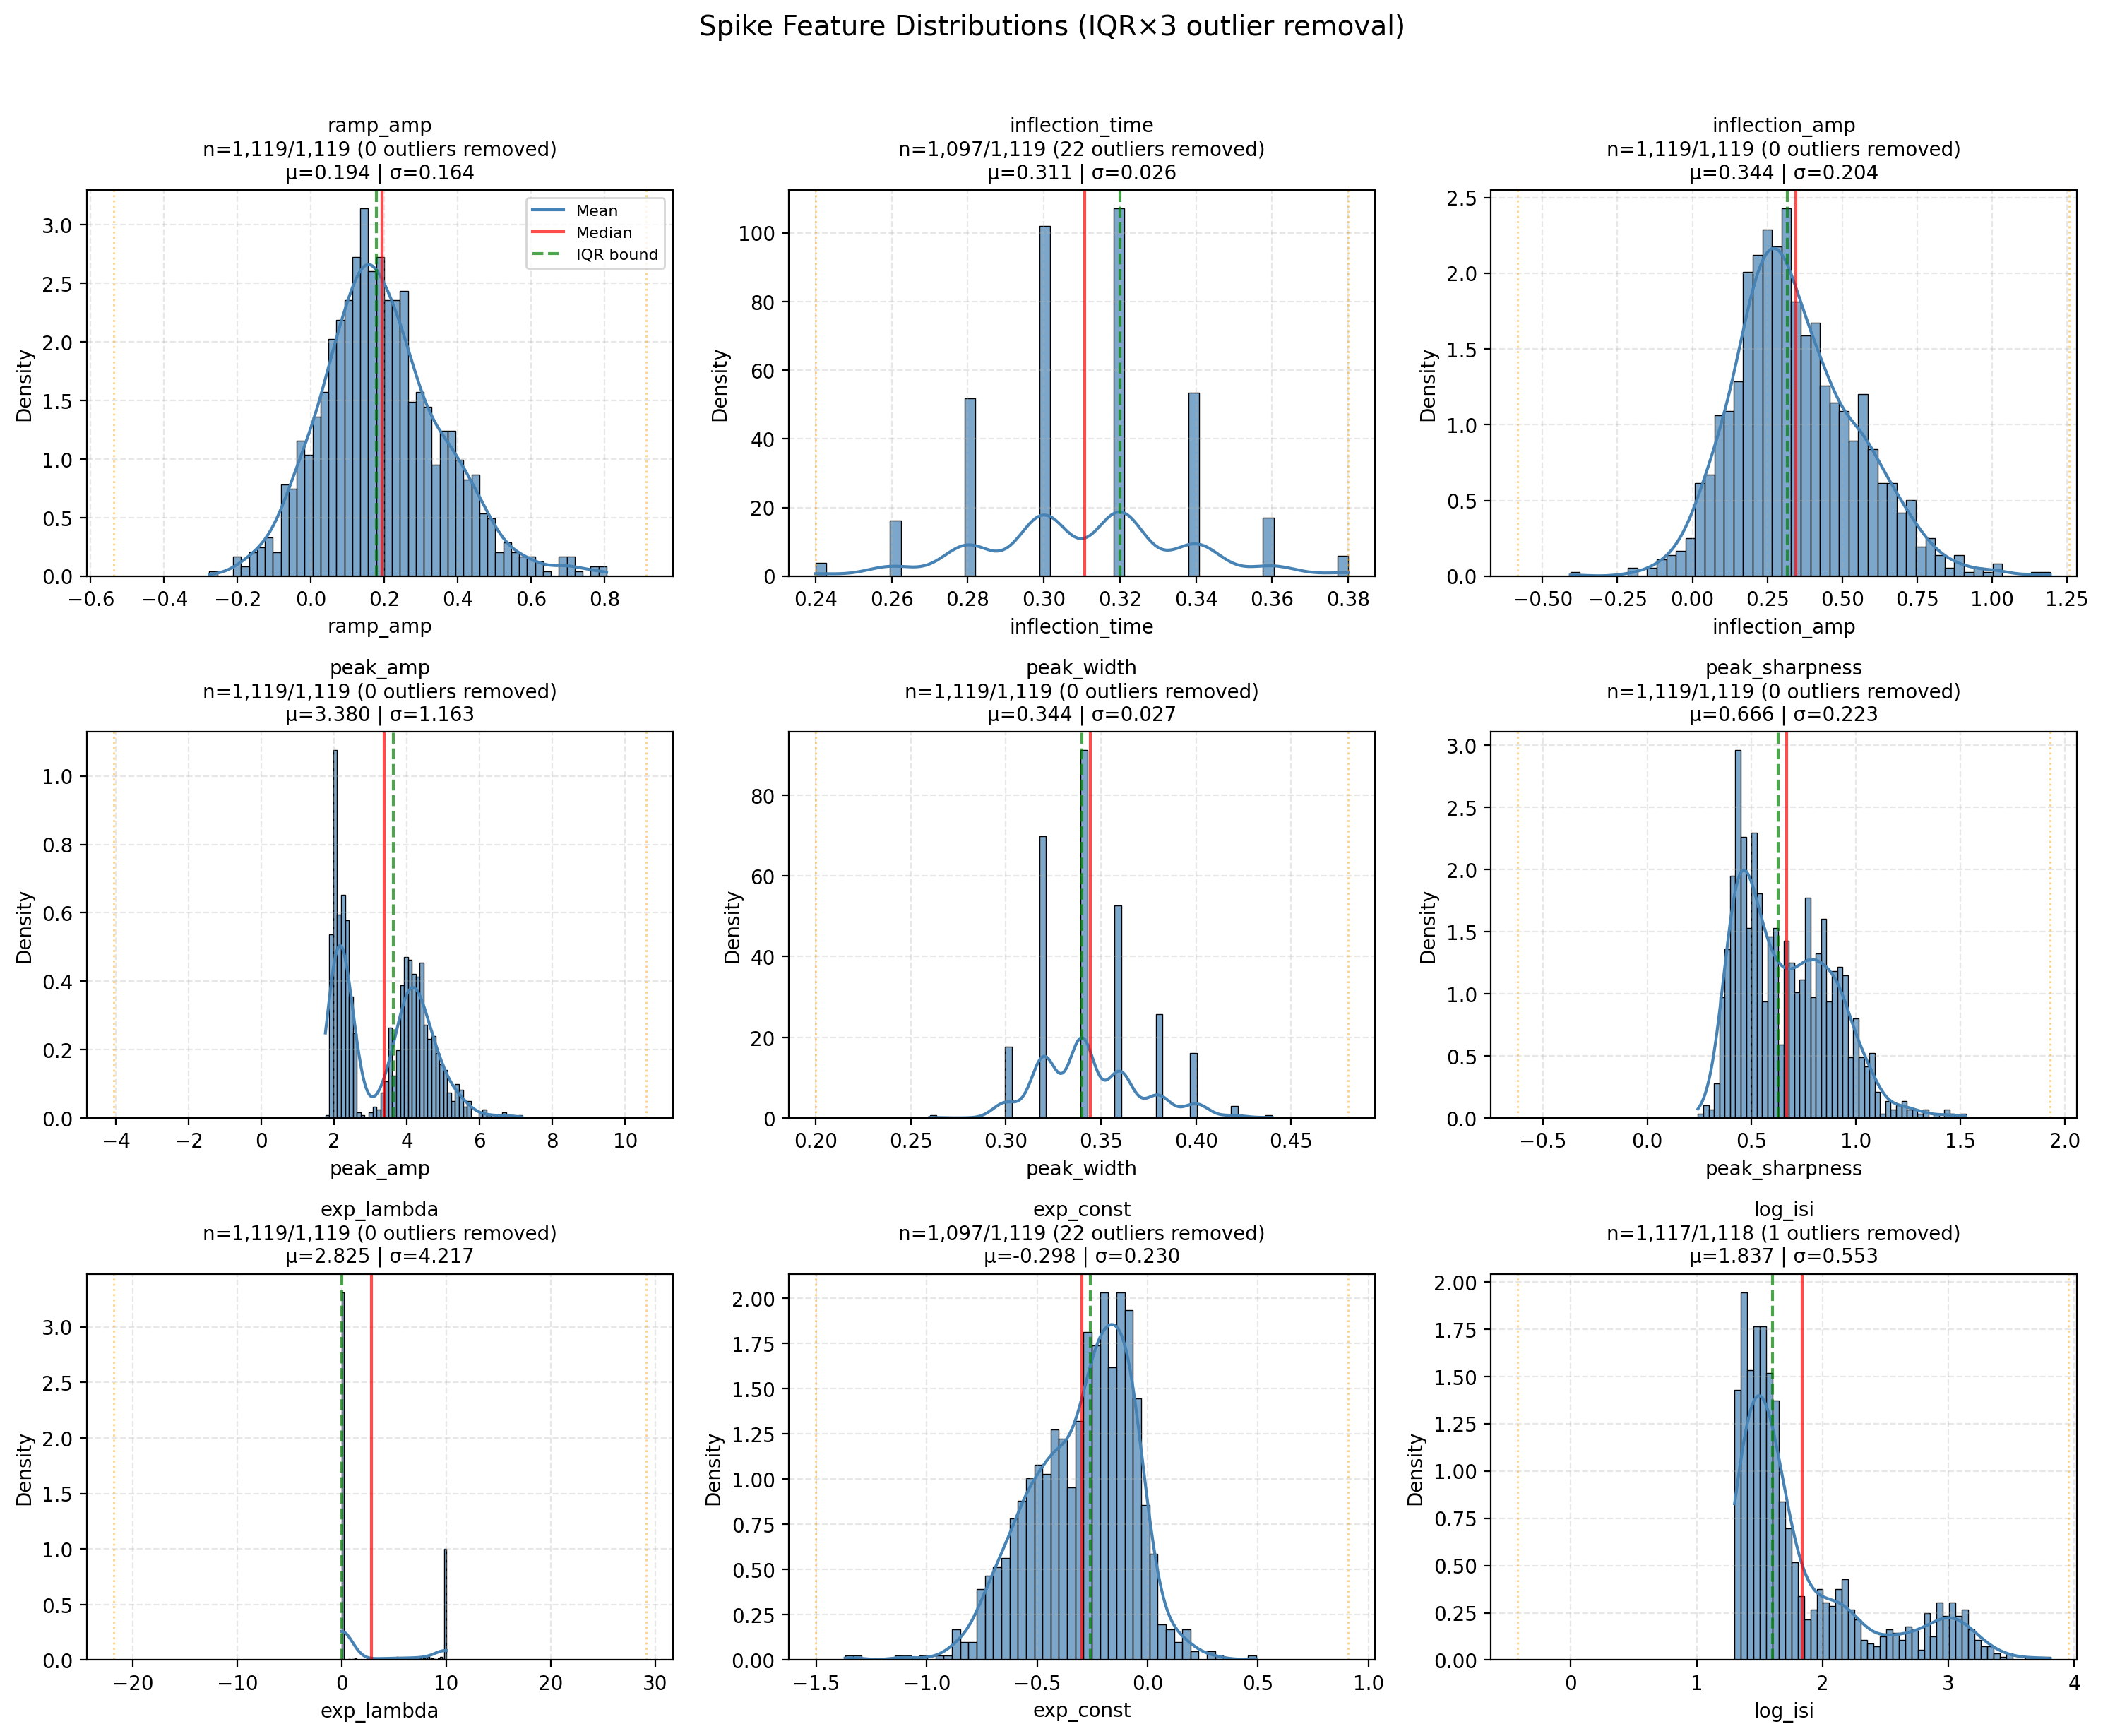


FEATURE DISTRIBUTION SUMMARY
Feature              Total N    Clean N    Outliers   % Removed  Mean       Std       
------------------------------------------------------------------------------------------
ramp_amp             1119       1119       0          0.0        0.194      0.164     
inflection_time      1119       1097       22         2.0        0.311      0.026     
inflection_amp       1119       1119       0          0.0        0.344      0.204     
peak_amp             1119       1119       0          0.0        3.380      1.163     
peak_width           1119       1119       0          0.0        0.344      0.027     
peak_sharpness       1119       1119       0          0.0        0.666      0.223     
exp_lambda           1119       1119       0          0.0        2.825      4.217     
exp_const            1119       1097       22         2.0        -0.298     0.230     
log_isi              1118       1117       1          0.1        1.837      0.553     


In [15]:
plot_spike_feature_distributions(df_features)

ramp_amp: Skipped - k_suggest = 1
→ inflection_time: Skipping (feature ignored).
inflection_amp: Skipped - k_suggest = 1


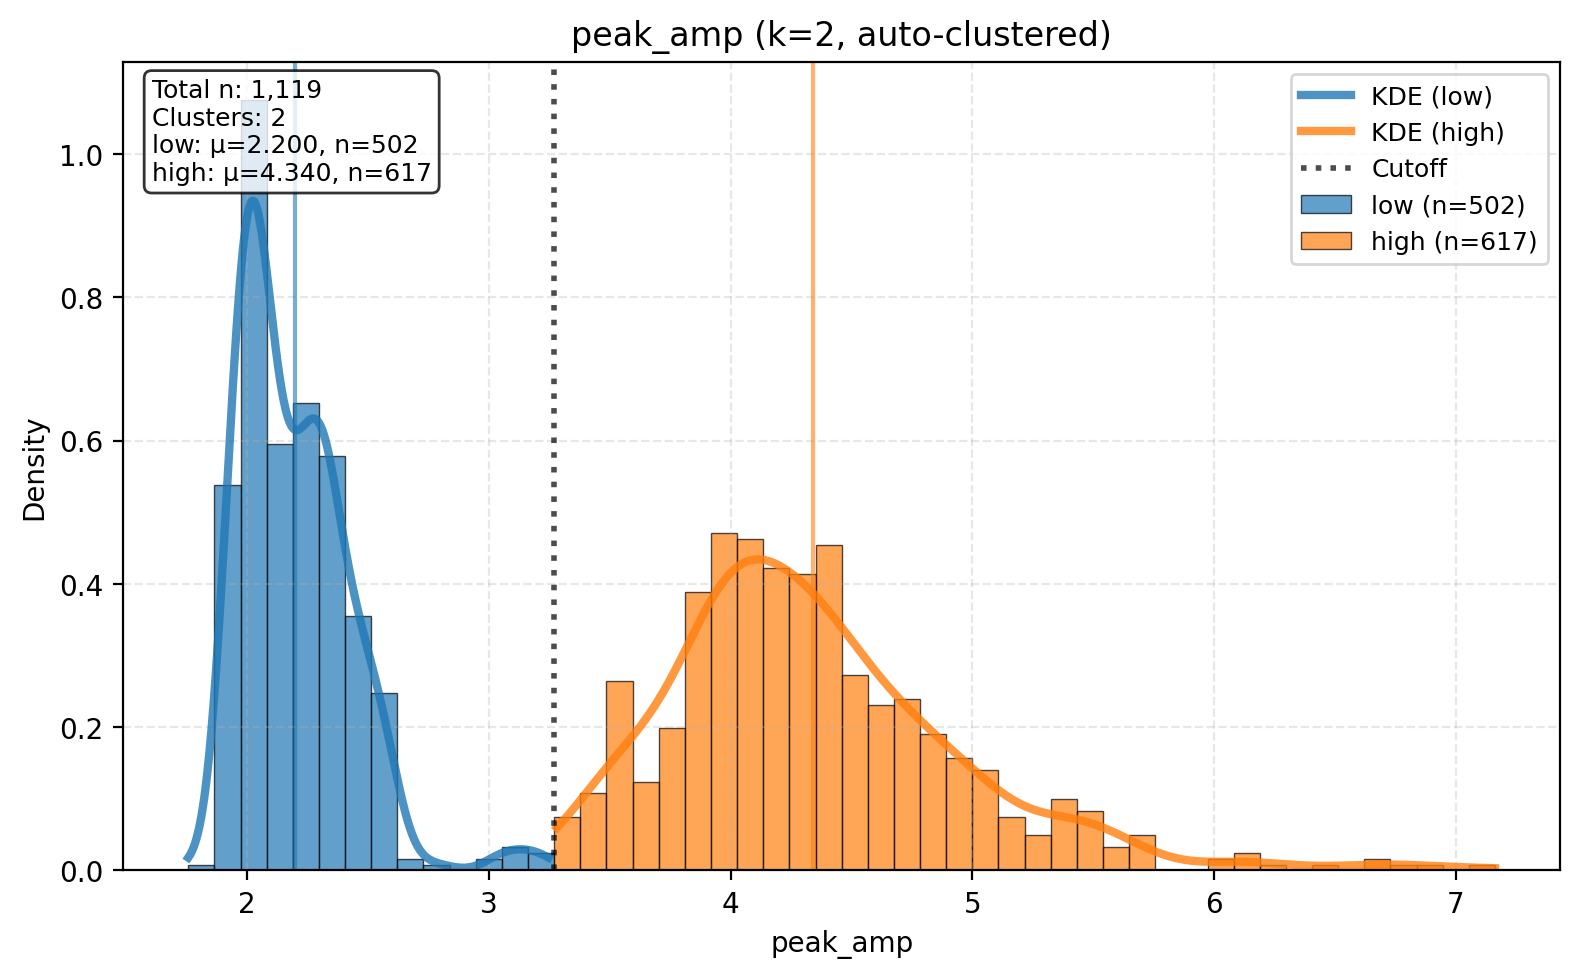

peak_width: Skipped - k_suggest = 1


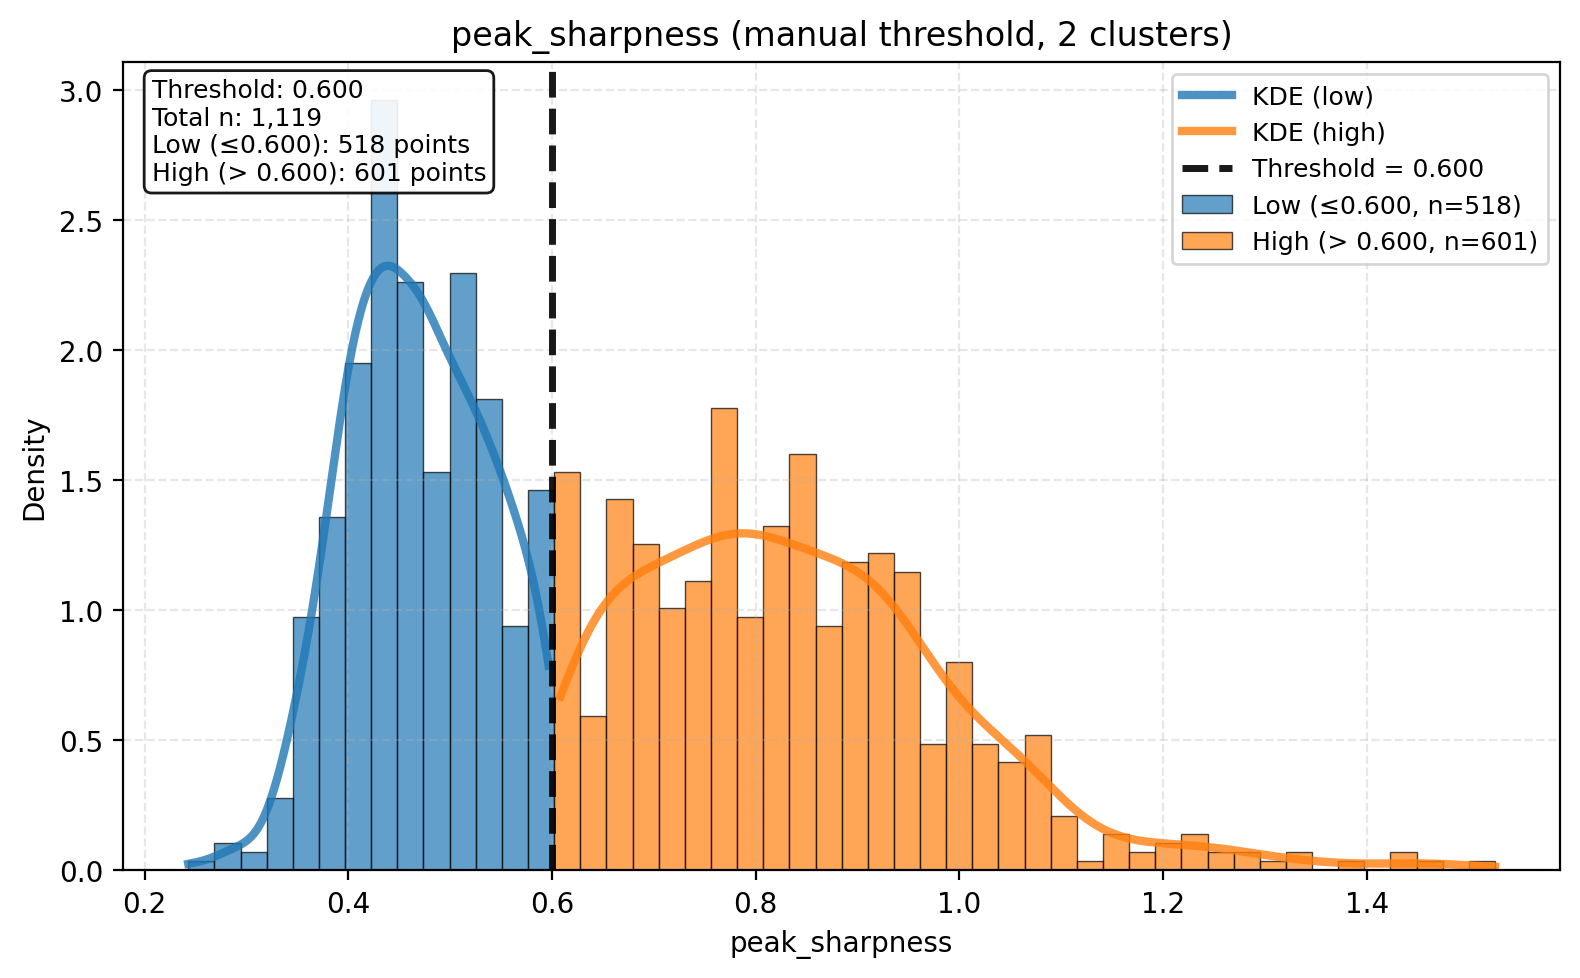

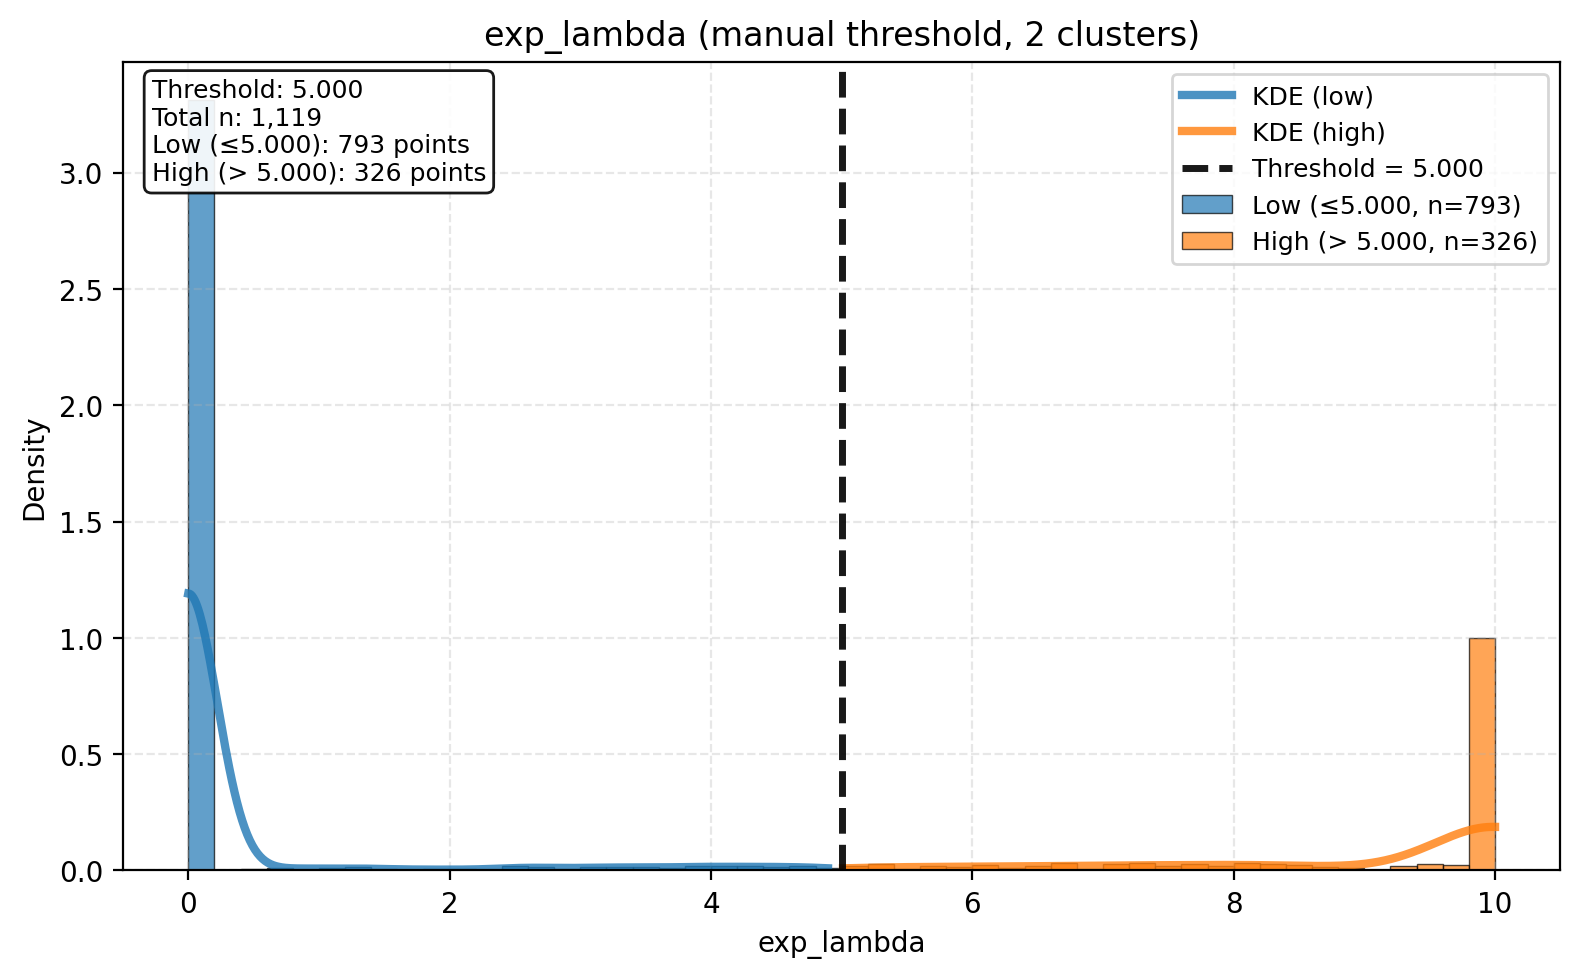

exp_const: Skipped - k_suggest = 1


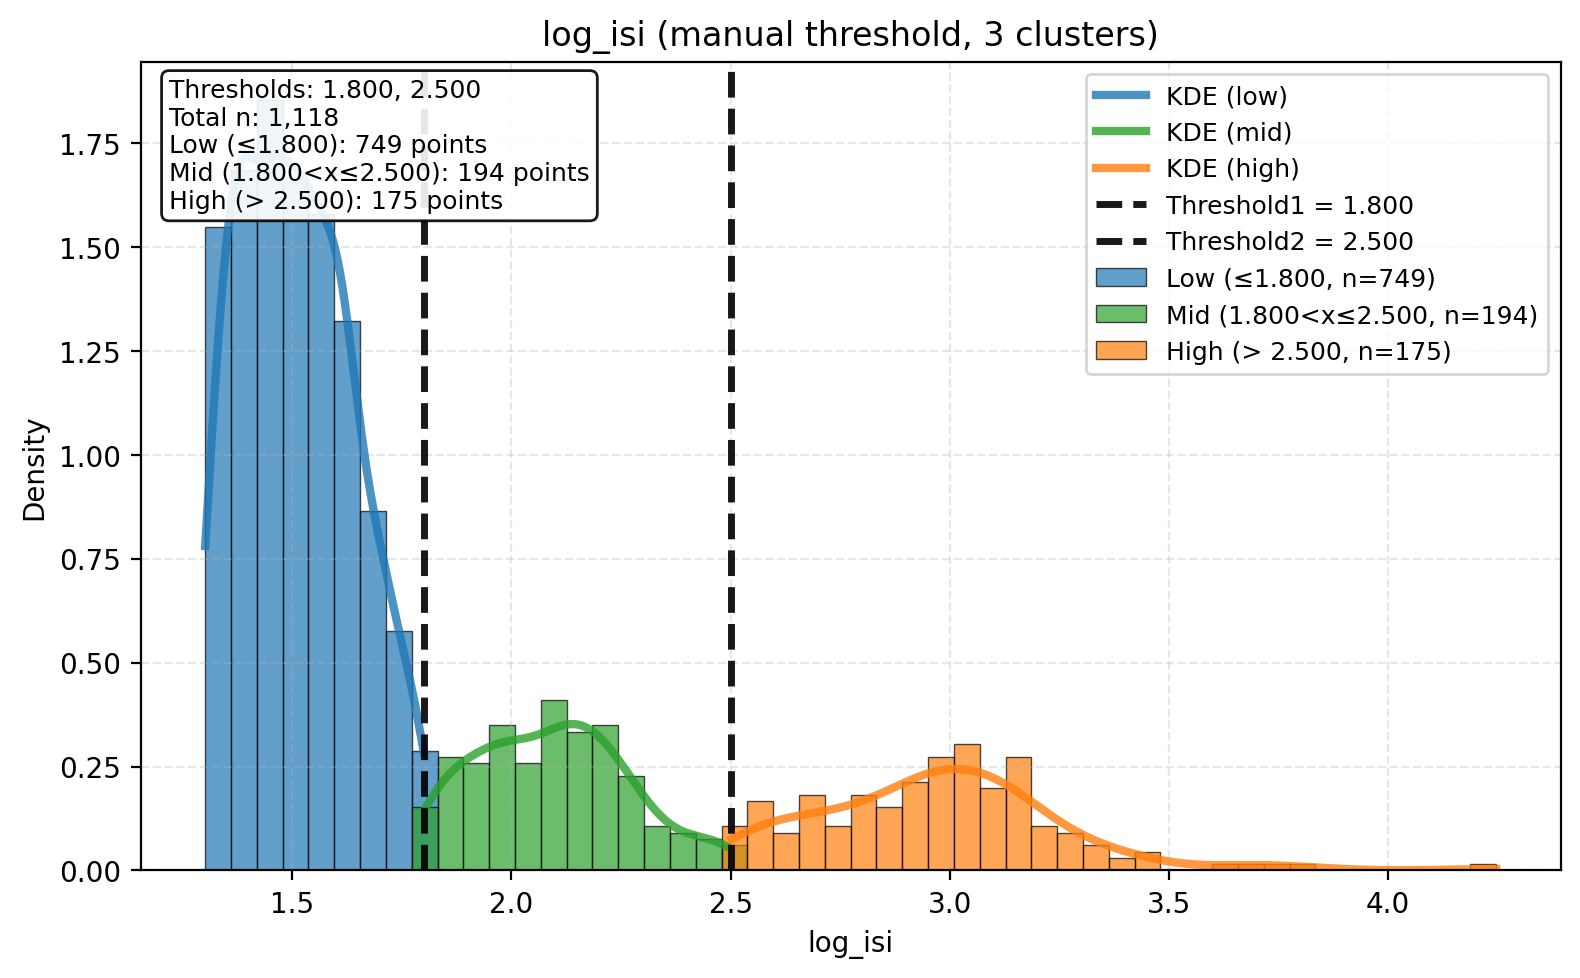

spk_times_ms: Skipped - k_suggest = 1
spk_id: Skipped - k_suggest = 1


In [16]:
# scan all numeric features and only cluster the ones that look multimodal
df_features_clust, rep = cluster_multimodal_features(
    df_features.drop(["spk_times_idx"], axis = 1),
    max_k=3,
    suffix="_cluster",ignore_features = "inflection_time",
    plot_each=True,  # set True if you want a quick plot per clustered feature, 
    manual_thresholds={"peak_sharpness":0.6, "exp_lambda": 5, "log_isi":(1.8, 2.5),
        
    }
)







In [17]:
df_features_clust

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,spk_times_ms,spk_id,peak_amp_cluster,peak_sharpness_cluster,exp_lambda_cluster,log_isi_cluster
0,0.009837,0.32,0.467007,4.066770,0.38,0.776966,1.030429,-0.350241,1.501946,208.480268,0,high,high,low,low
1,0.047172,0.30,0.400746,4.000609,0.36,0.822552,3.802945,-0.521668,1.422054,240.245073,1,high,high,low,low
2,-0.036794,0.34,0.292508,4.075305,0.36,0.623636,5.915424,-0.861539,2.034020,266.672431,2,high,high,high,mid
3,0.508333,0.32,0.288763,4.554854,0.38,0.882994,10.000000,-0.618316,1.597268,374.820695,3,high,high,high,low
4,0.242062,0.32,0.671918,4.696013,0.36,0.867873,6.667226,-0.435759,2.159420,414.381770,4,high,high,high,mid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1116,0.078585,0.30,0.326825,1.944270,0.32,0.381207,0.000018,-0.056124,3.809923,227745.772080,1114,low,low,low,high
1117,0.012062,0.26,0.512724,1.945625,0.26,0.412176,0.000022,-0.021553,3.639914,234201.163981,1115,low,low,low,high
1118,0.156769,0.30,0.425757,2.136809,0.32,0.399556,0.000017,0.129661,4.246379,238565.456212,1116,low,low,low,high
1119,0.148740,0.34,0.467079,2.022752,0.34,0.353169,0.016804,-1.369796,3.694783,256200.580007,1117,low,low,low,high


### CLUSTER REPORTS


===== CLUSTER REPORT: peak_amp_cluster =====
Found 2 clusters: ['high', 'low']

→ Determining cluster colors and labels...
  Using existing cluster labels: ['high', 'low']
  Groups: ('low', 'high')
  Group names: ('Low', 'High')

→ 1. Plotting spike waveforms by cluster

→ 1.5 Average waveforms with visual RMSE


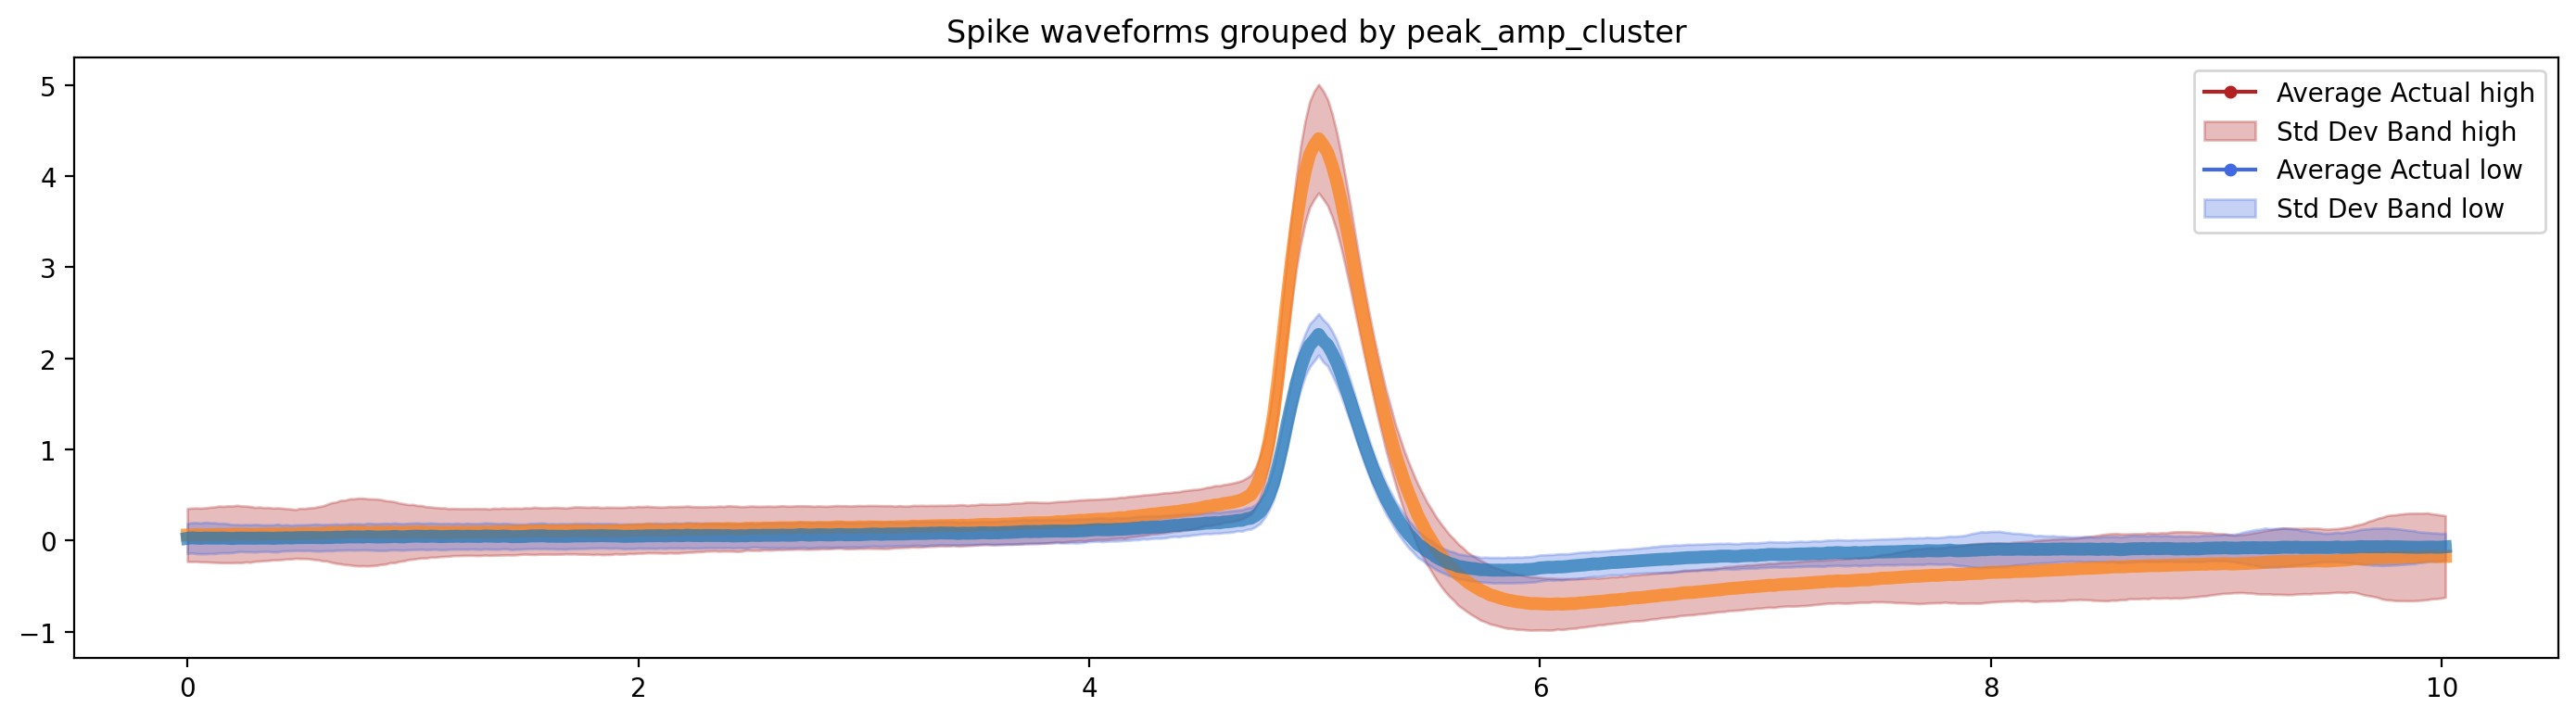

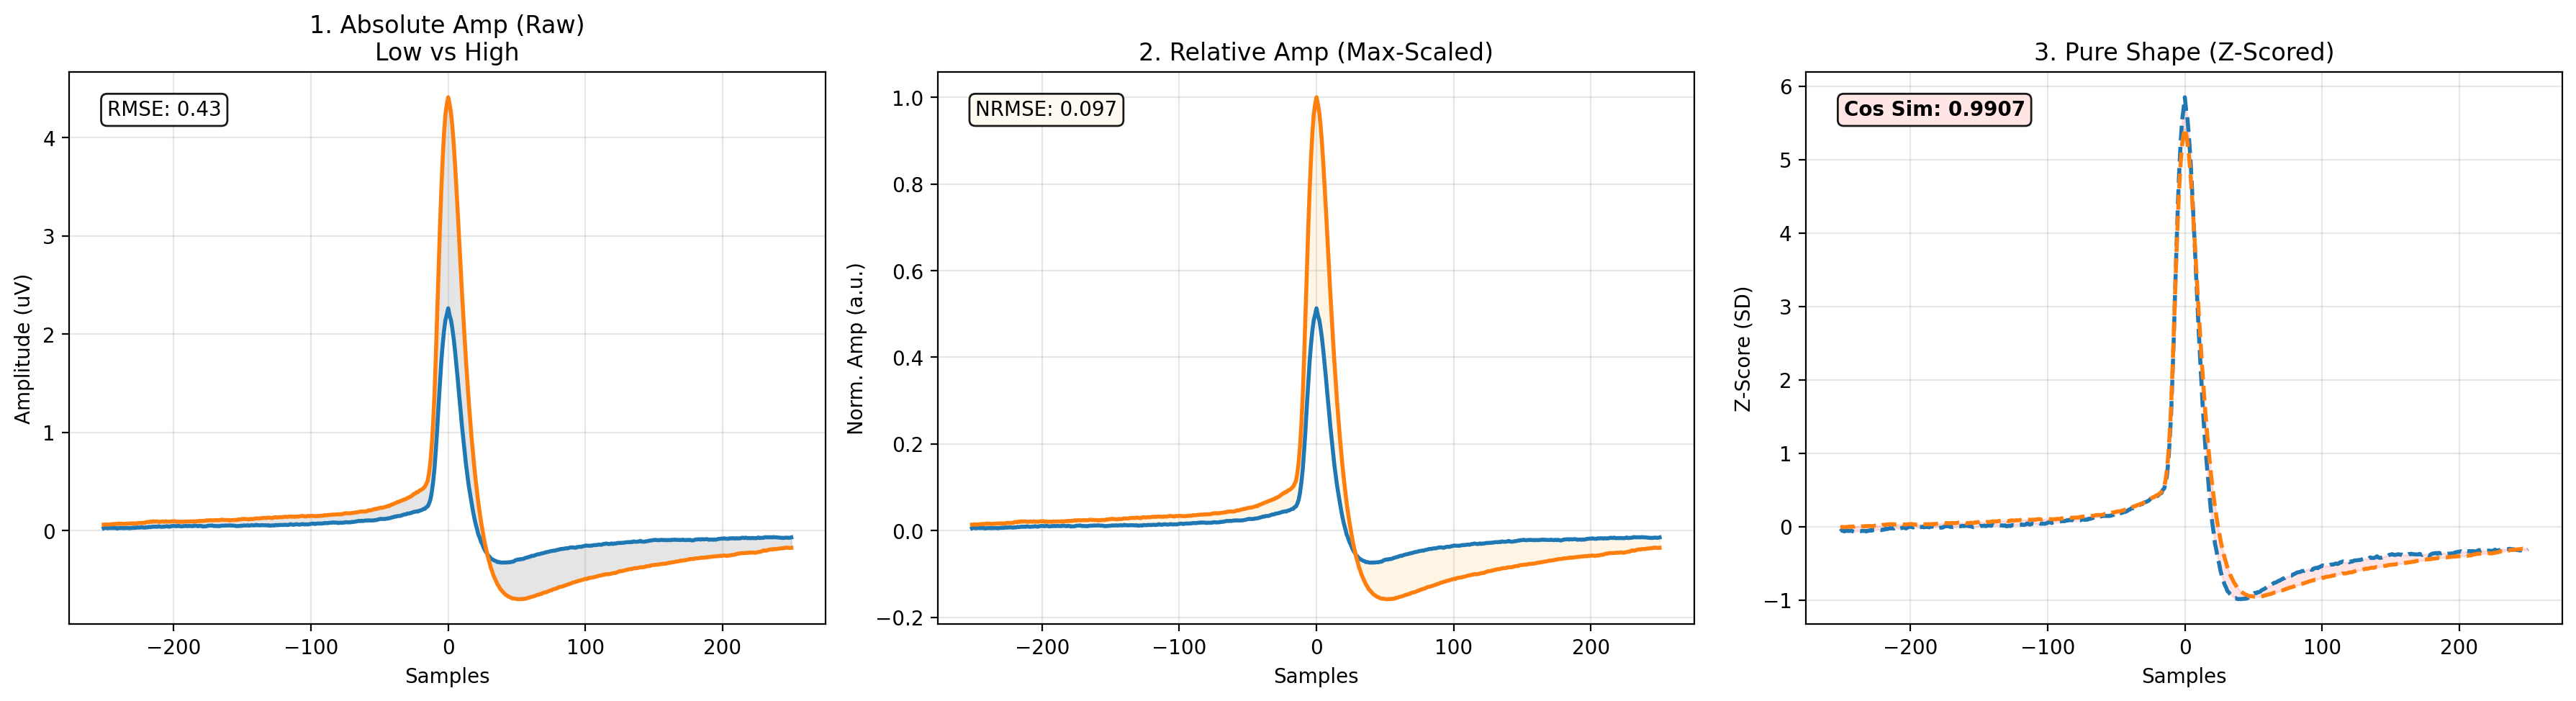


→ 2. Plotting cluster proportions over time


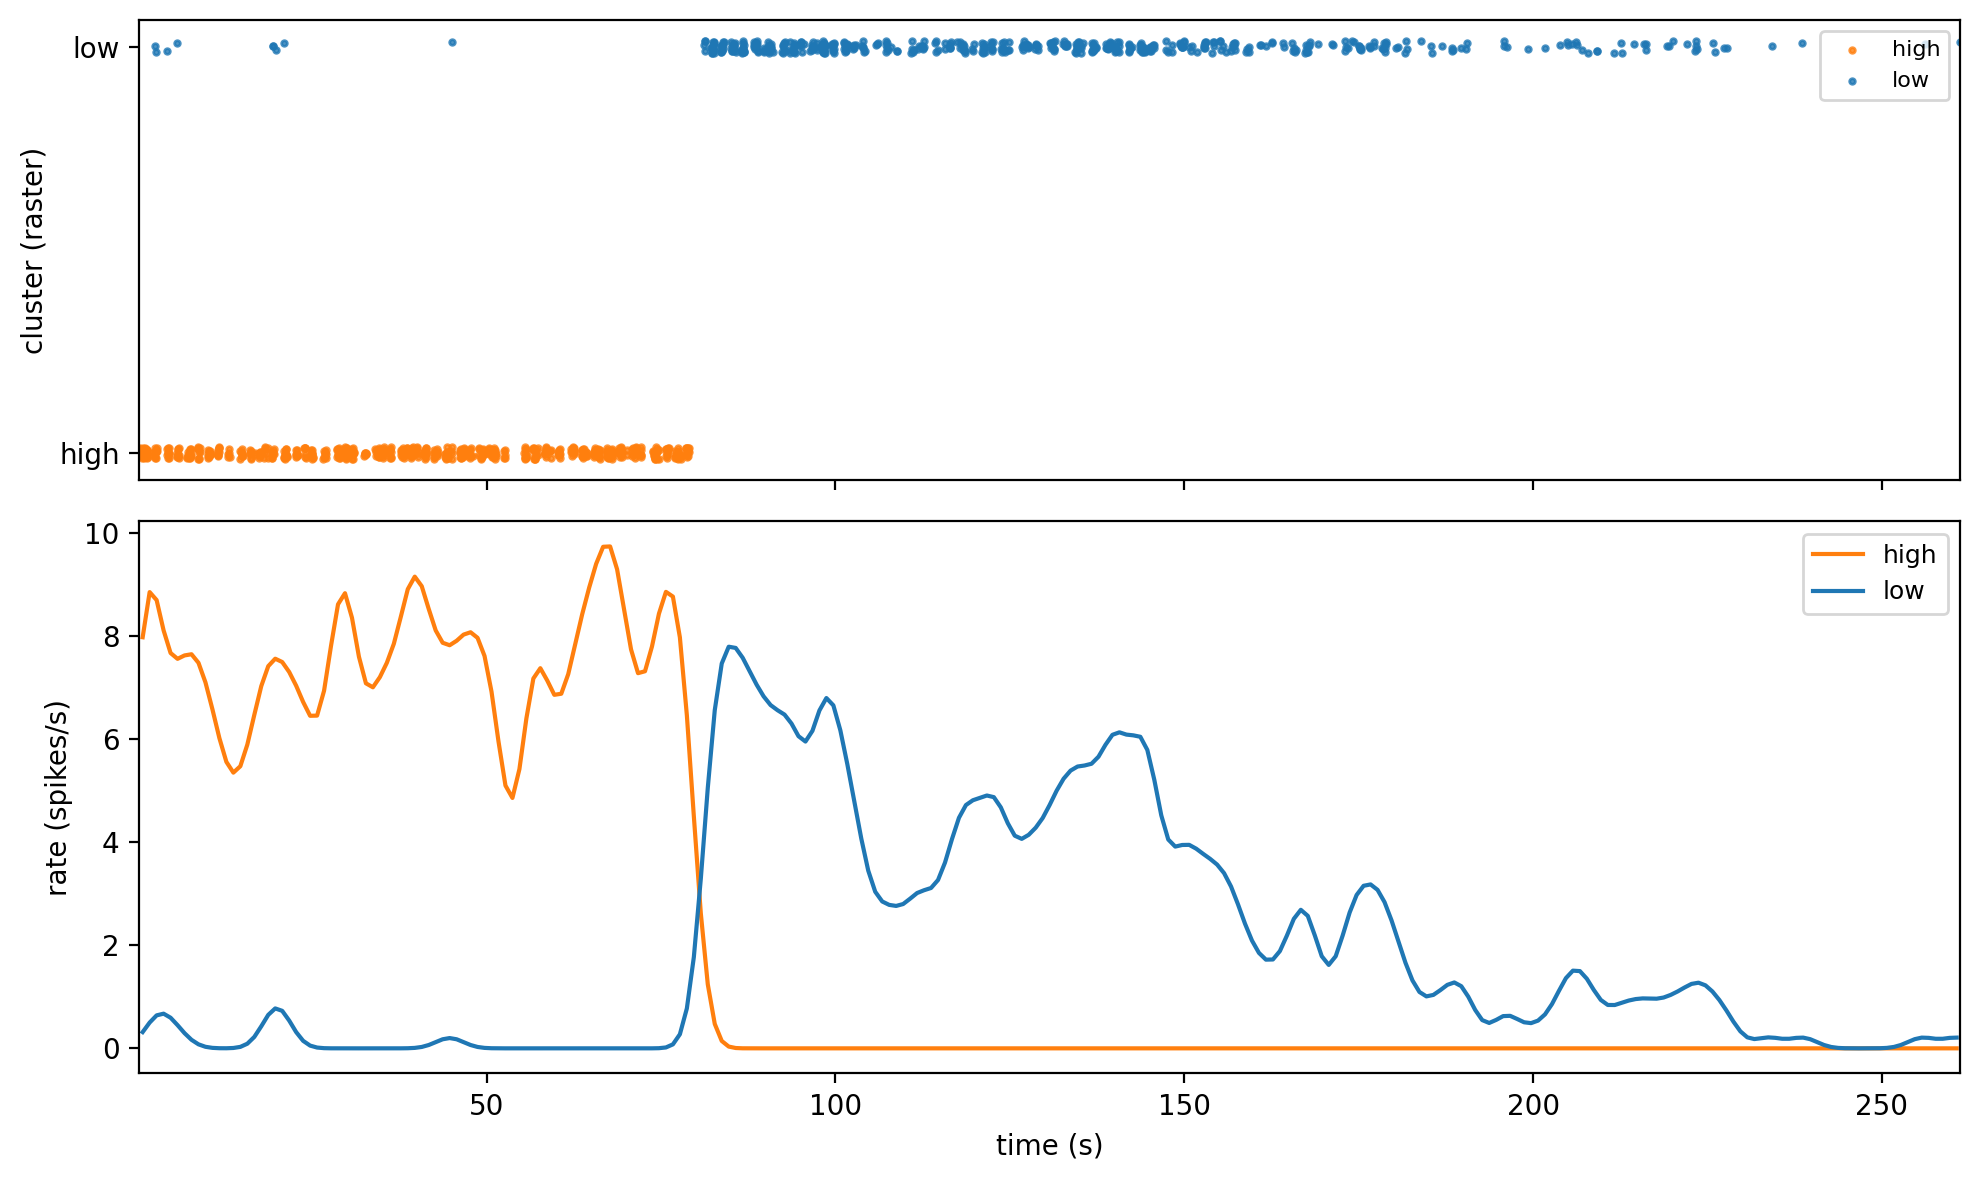


→ 3. Computing cluster transition matrix


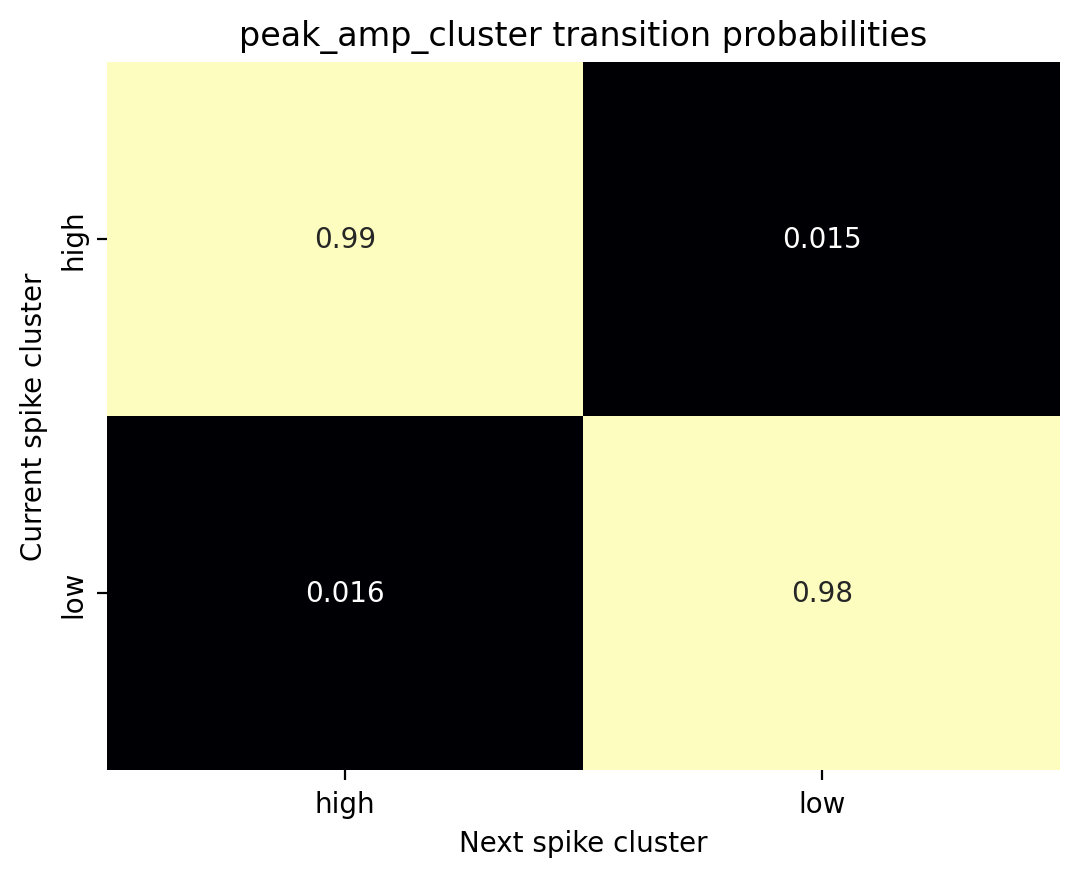


→ 4. Visualizing feature distributions by cluster


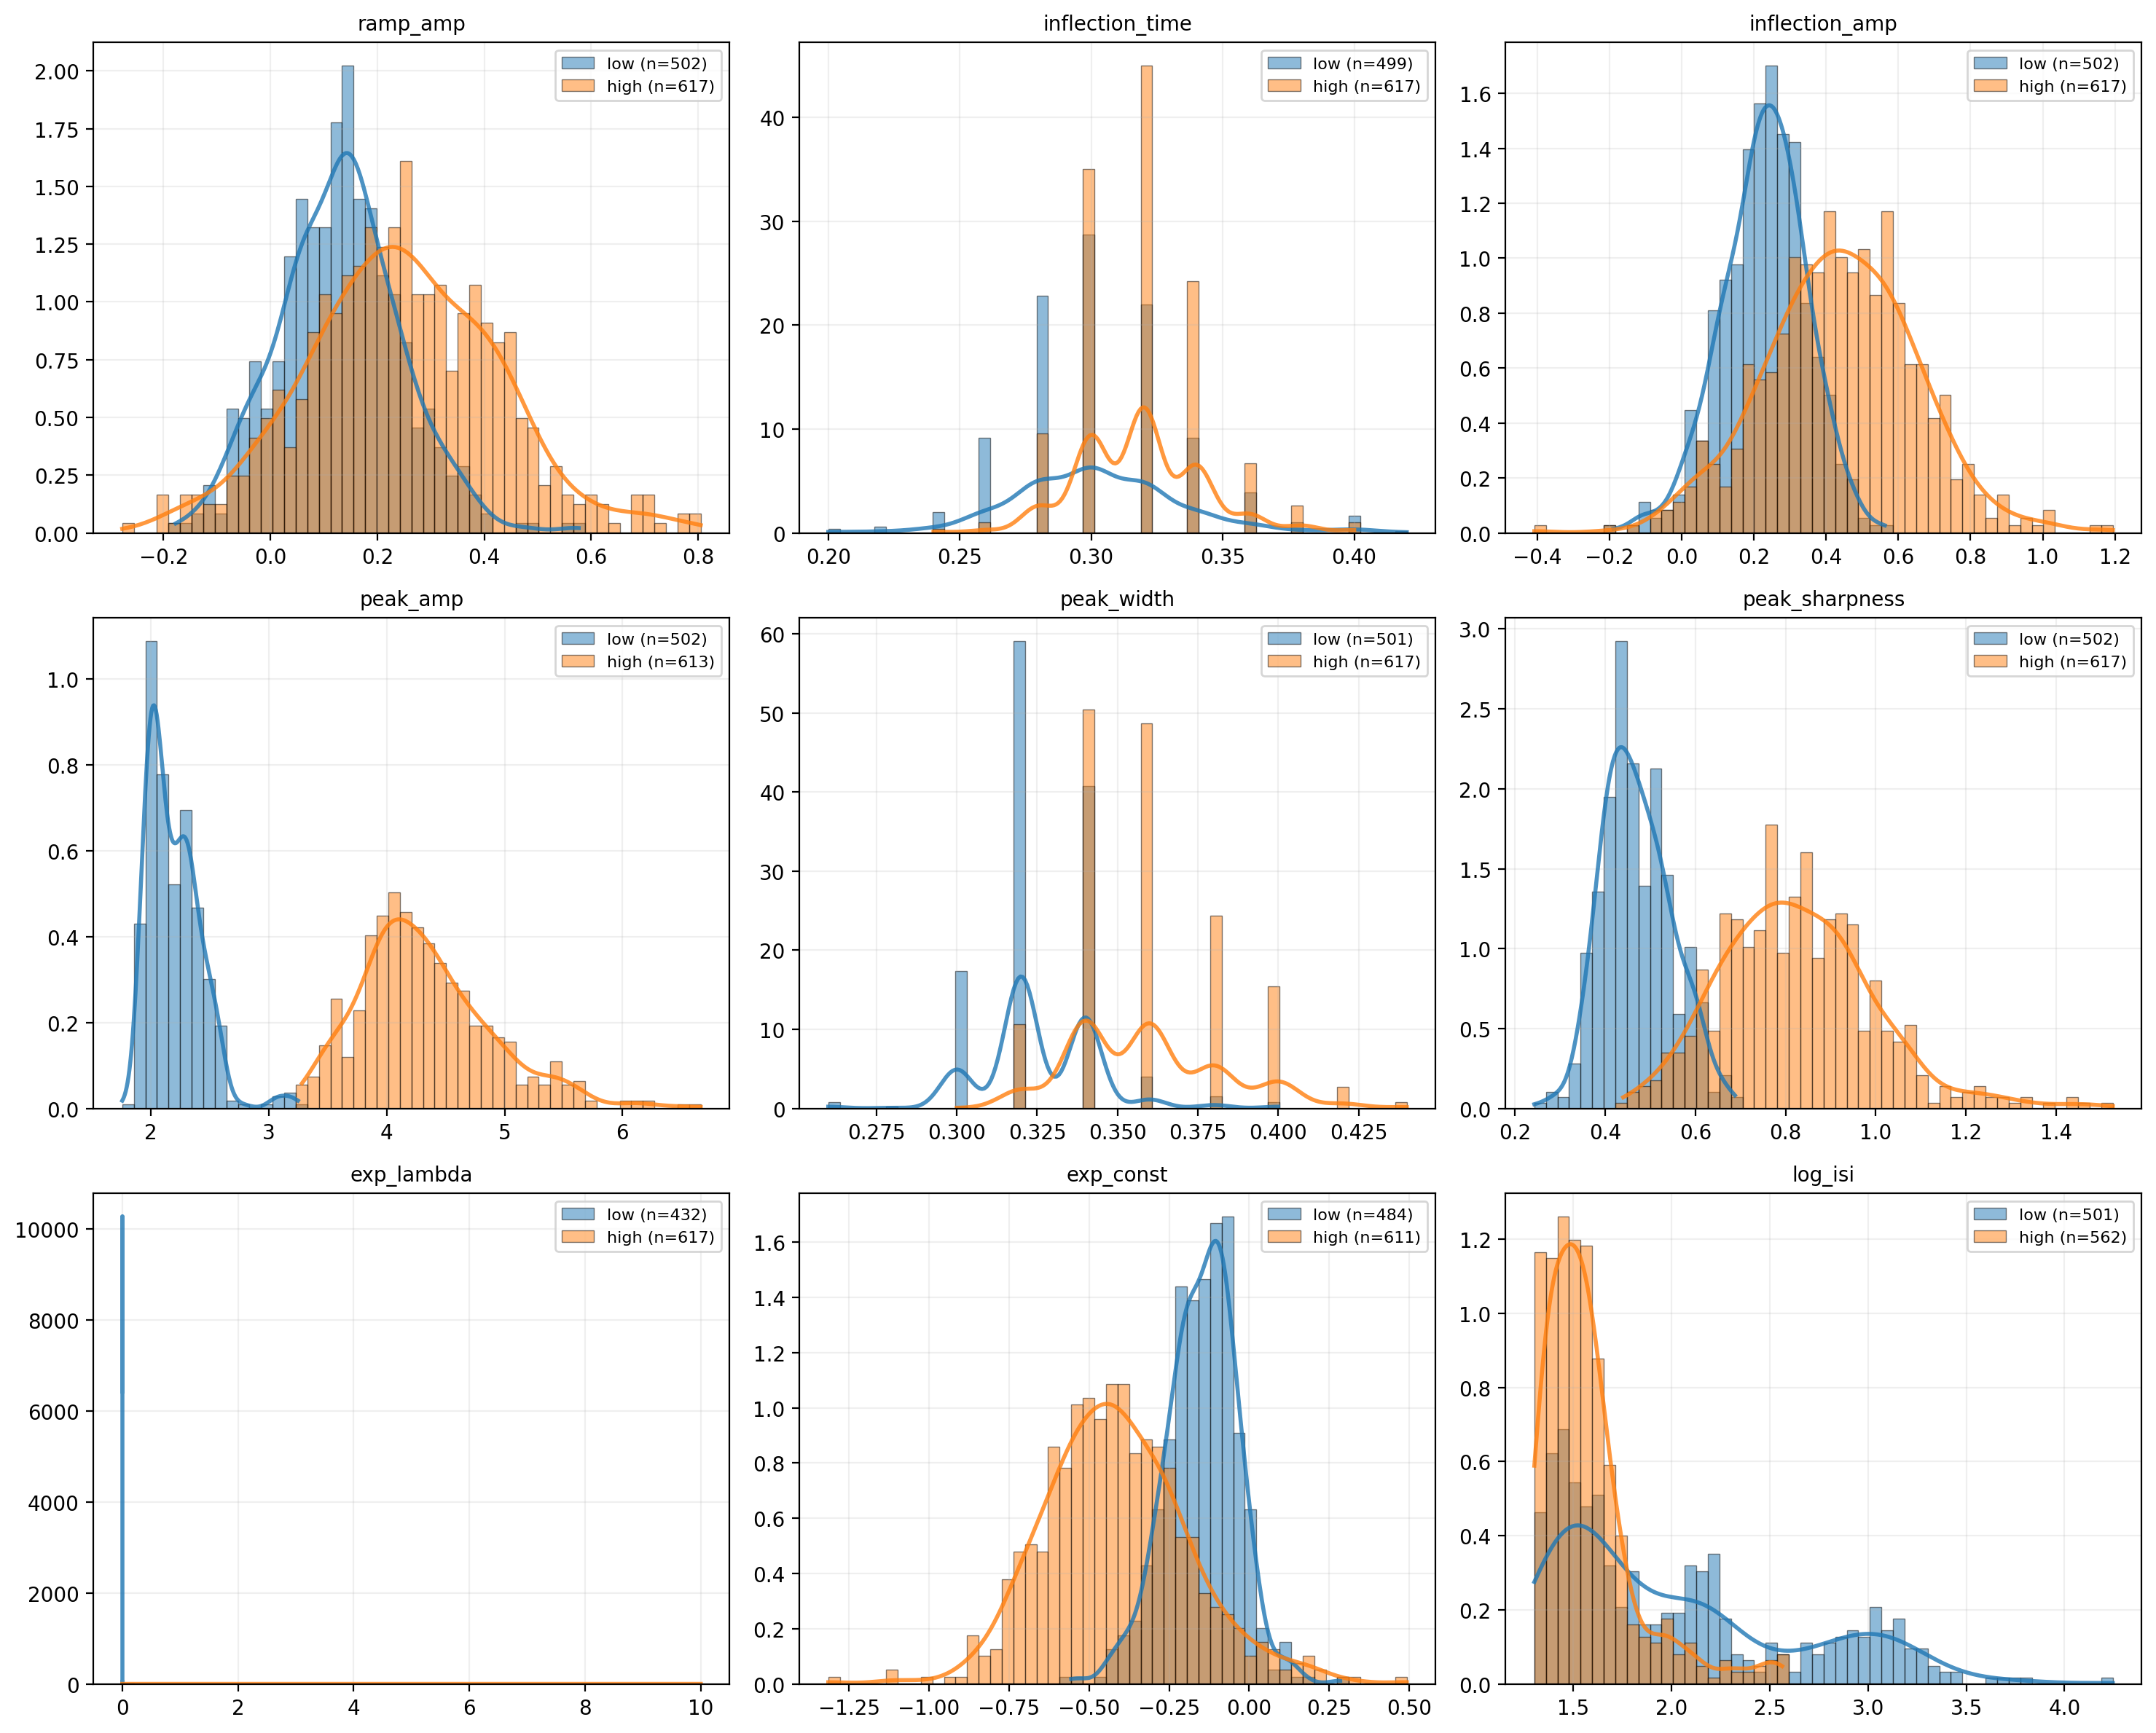


→ 5. Statistical analysis for: peak_amp
----------------------------------------

Test: Mann-Whitney U (nonparametric)
Number of groups: 2
P-value: 0.000000
Significance: ***
η² effect size: 0.839
Interpretation: Very Large


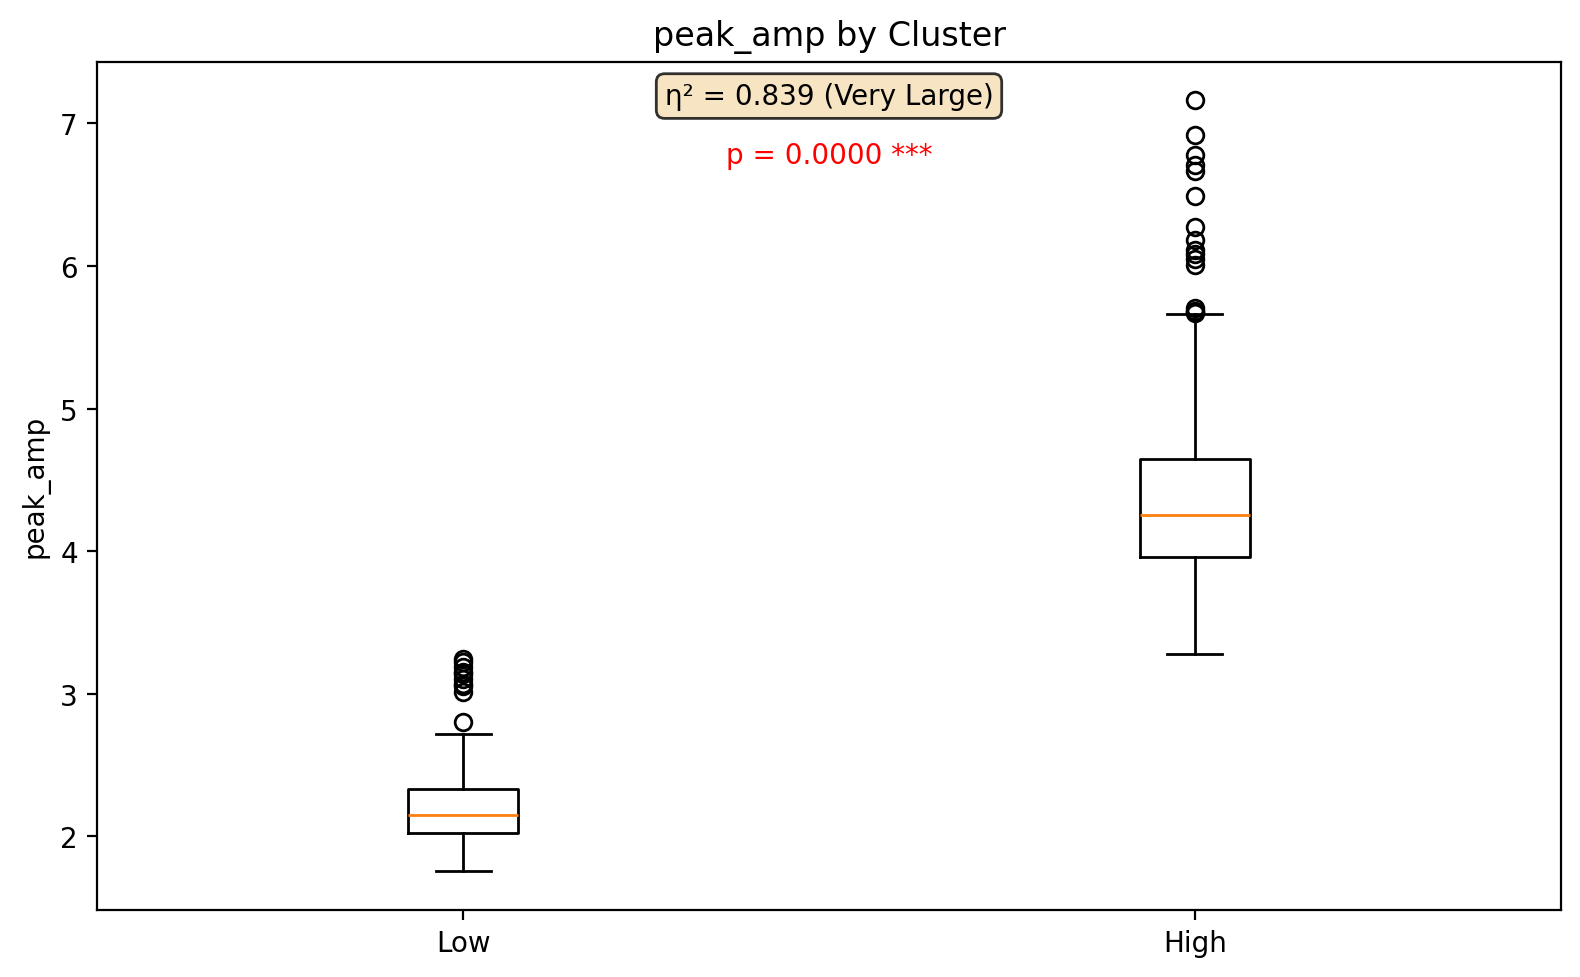


===== REPORT COMPLETE =====


===== CLUSTER REPORT: peak_sharpness_cluster =====
Found 2 clusters: ['high', 'low']

→ Determining cluster colors and labels...
  Using existing cluster labels: ['high', 'low']
  Groups: ('low', 'high')
  Group names: ('Low', 'High')

→ 1. Plotting spike waveforms by cluster

→ 1.5 Average waveforms with visual RMSE


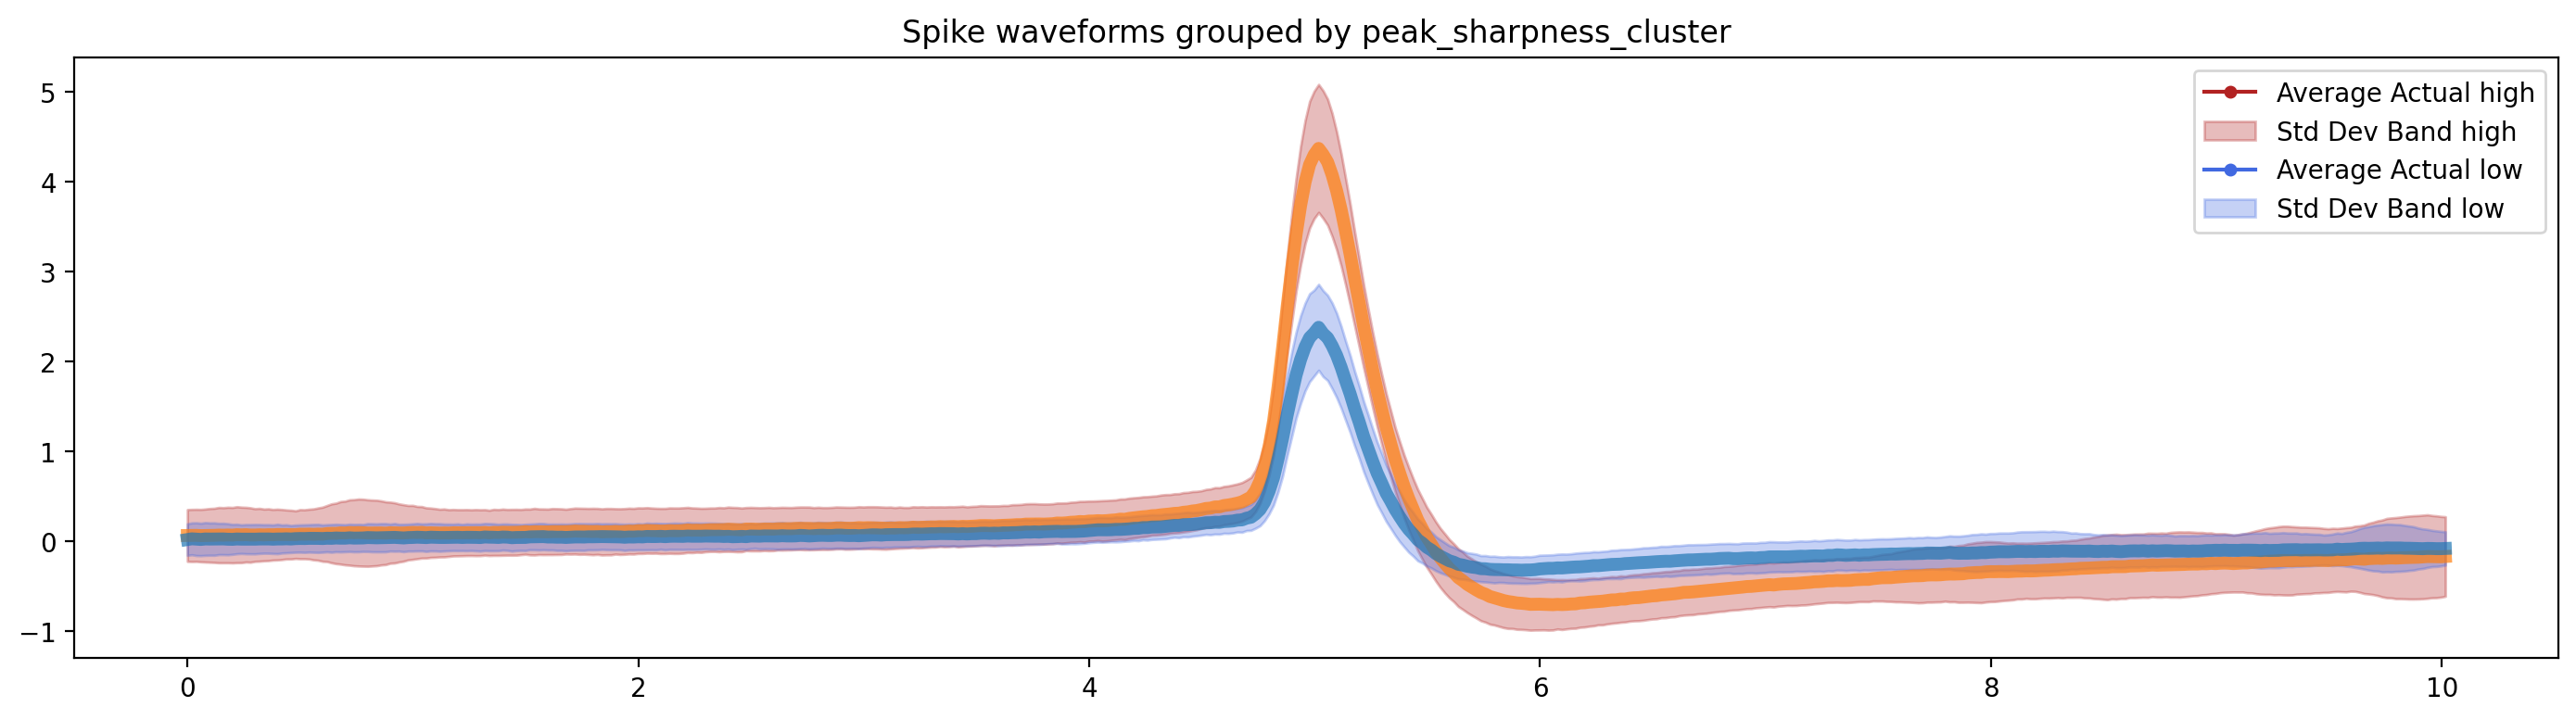

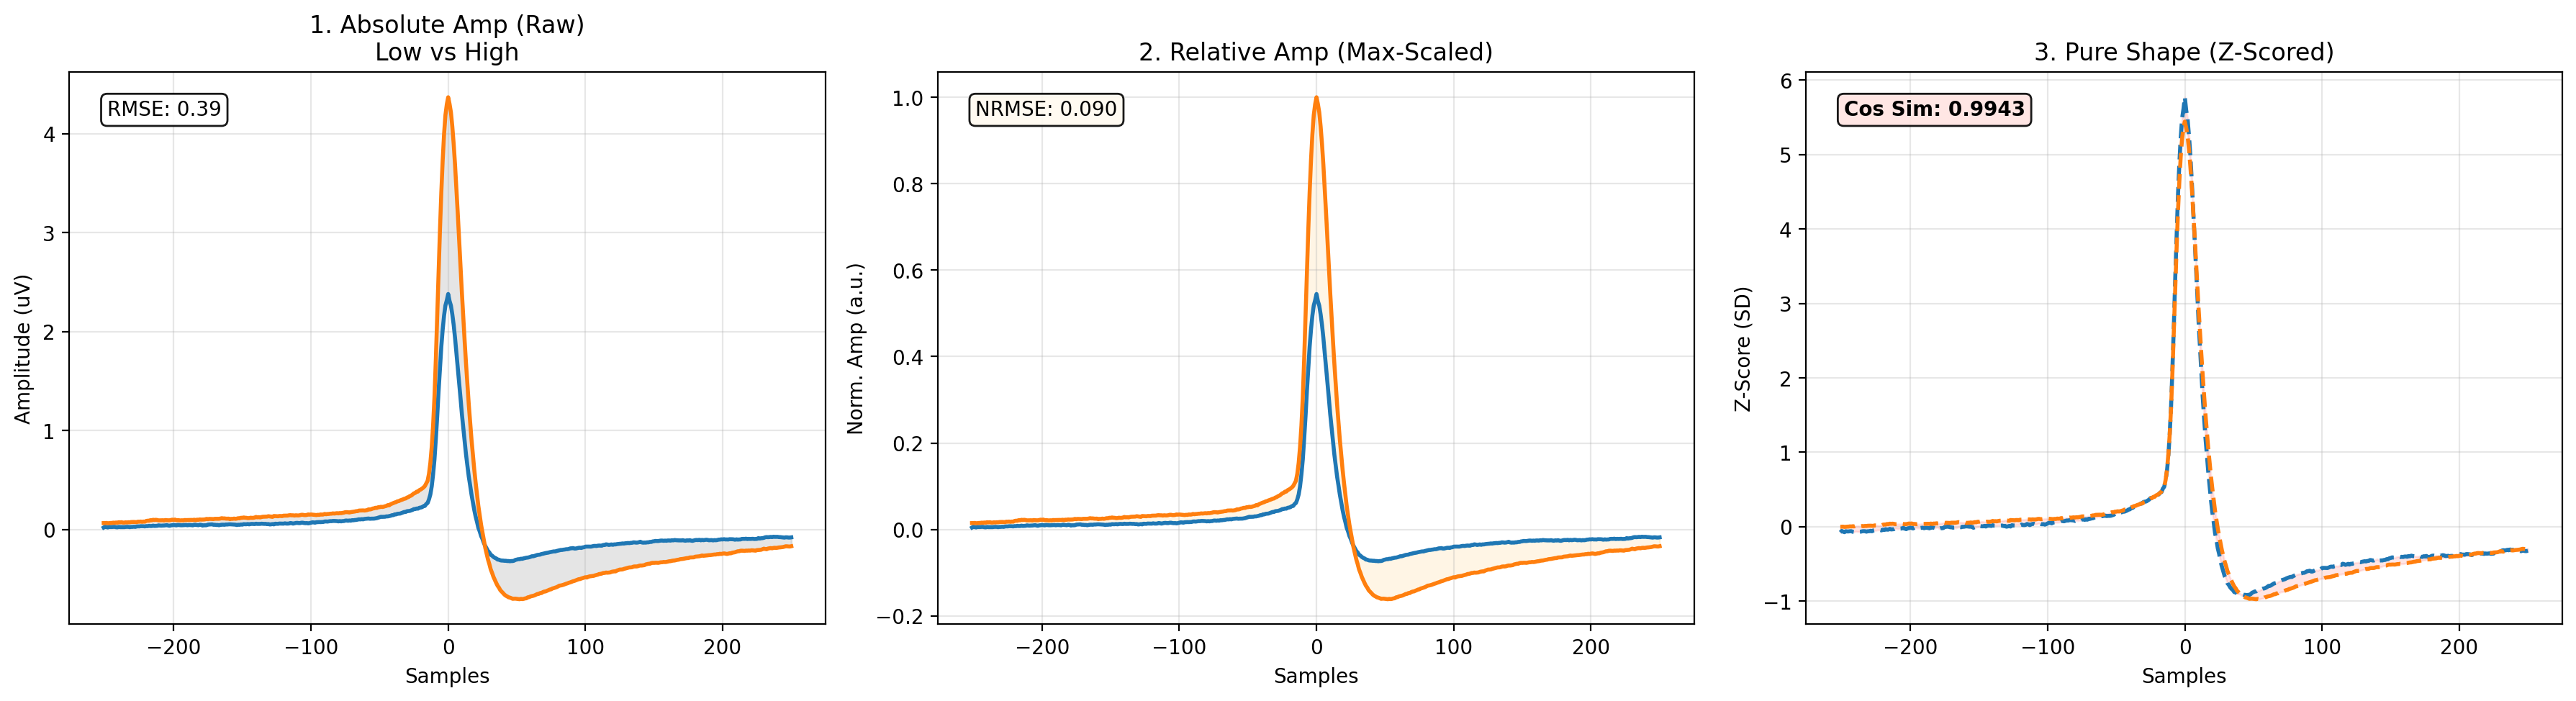


→ 2. Plotting cluster proportions over time


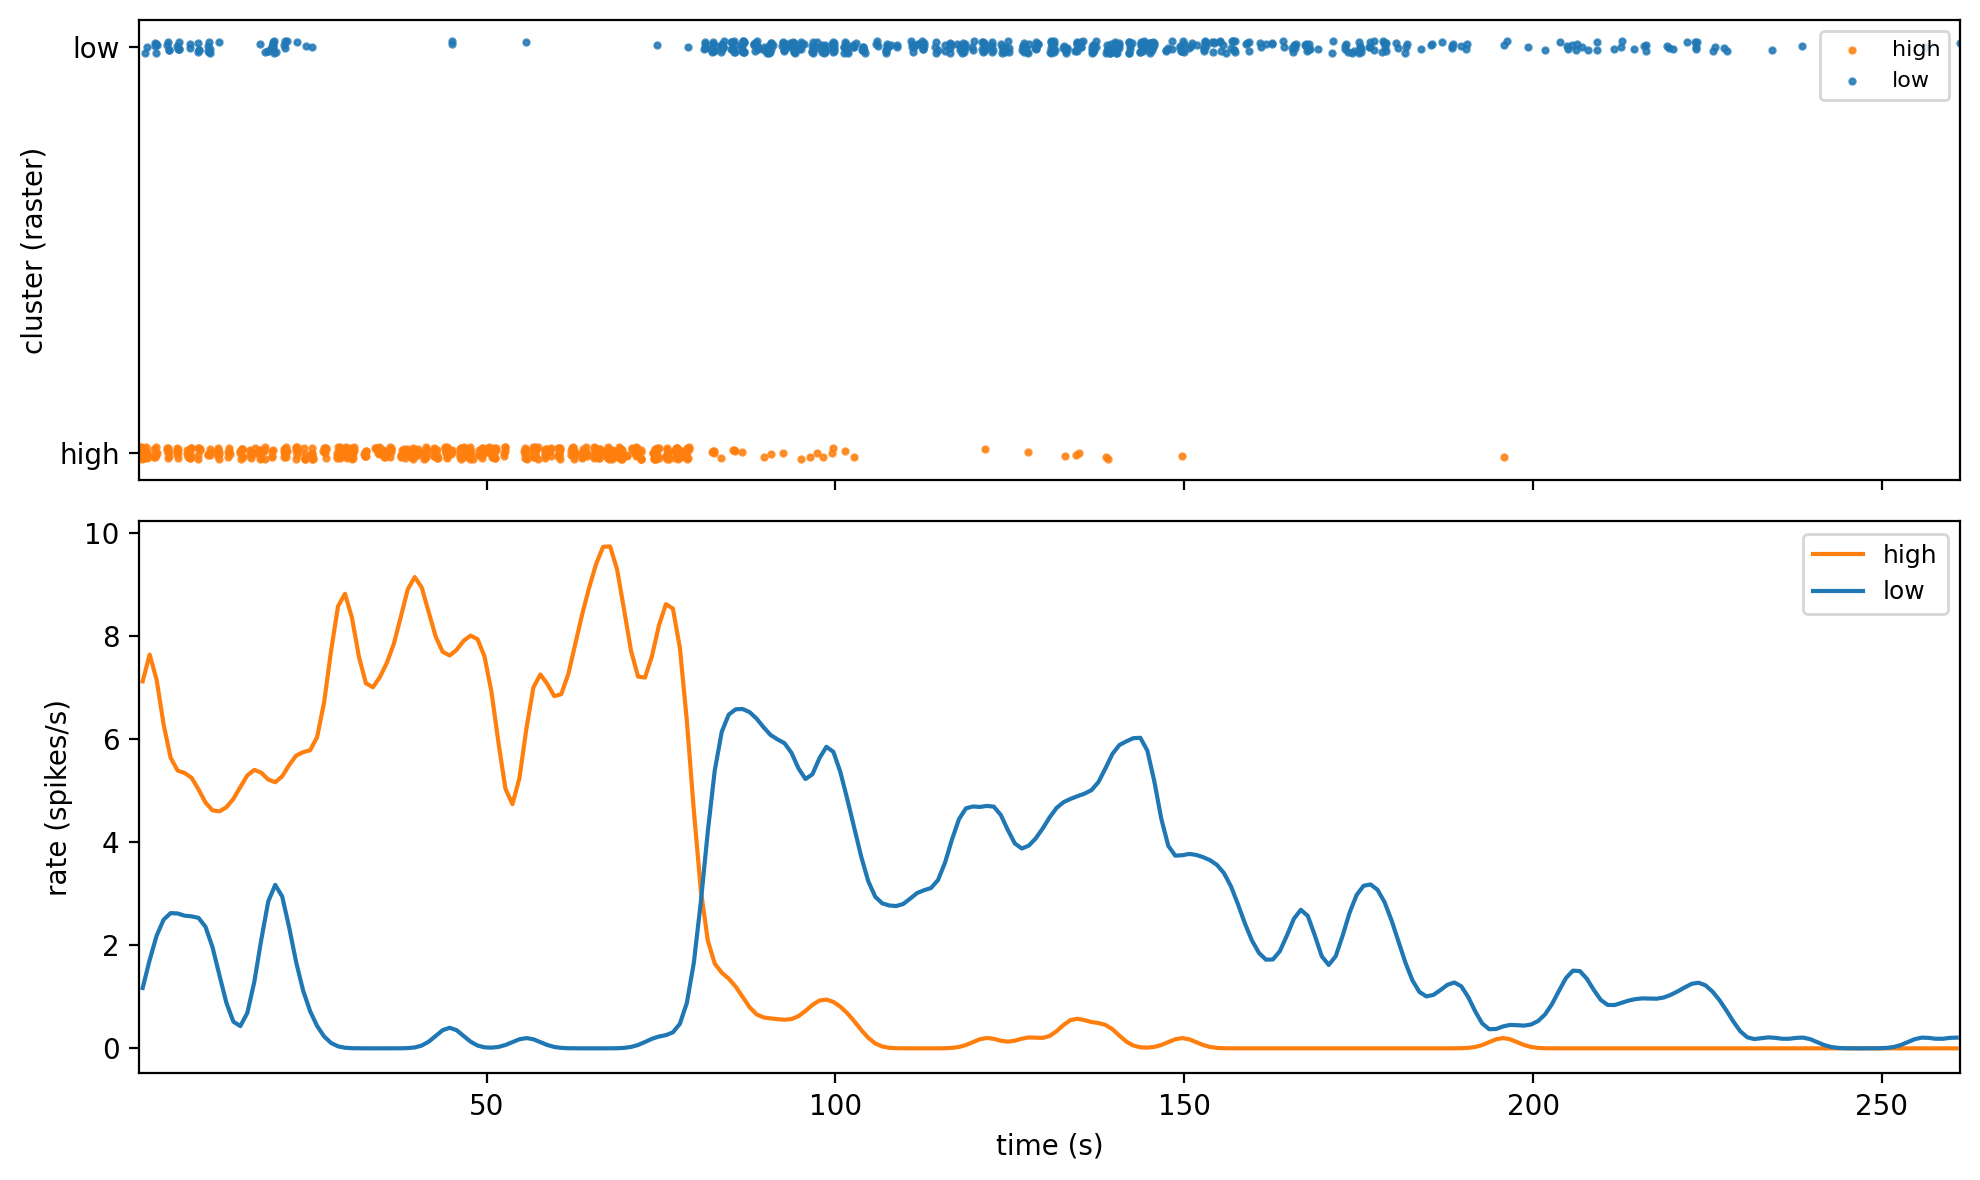


→ 3. Computing cluster transition matrix


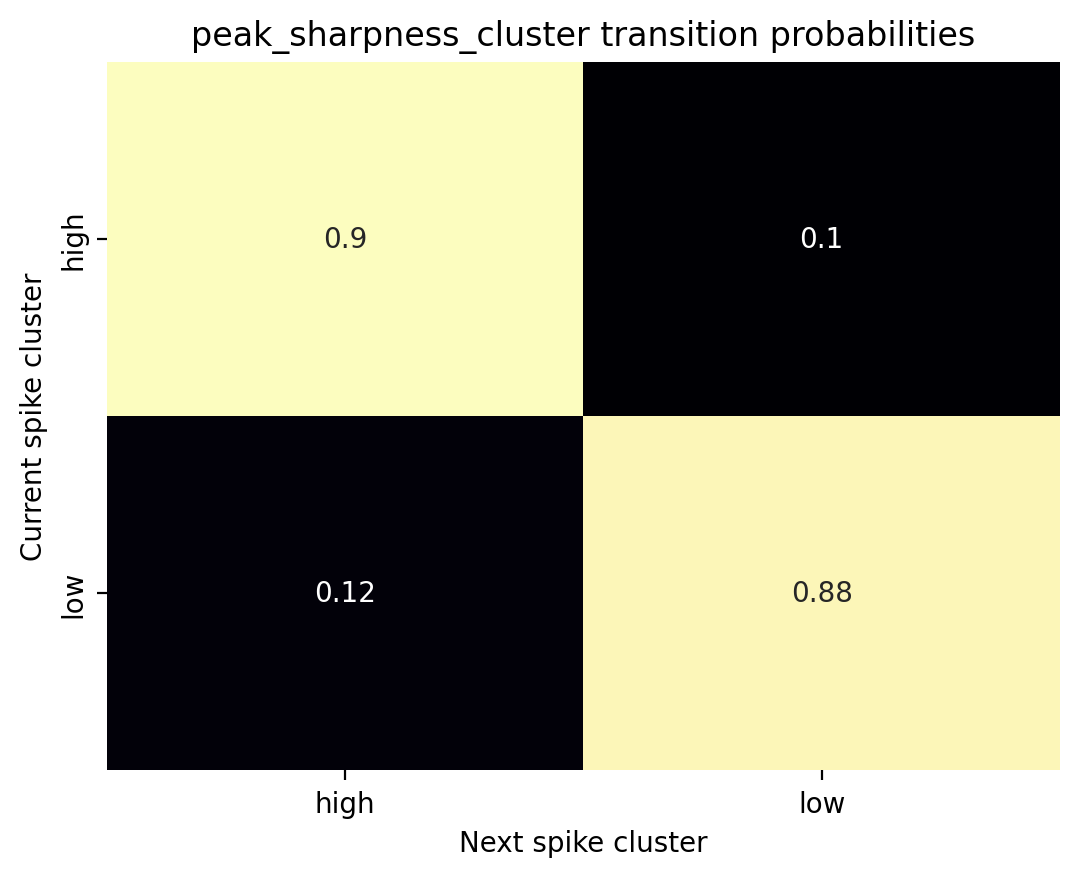


→ 4. Visualizing feature distributions by cluster


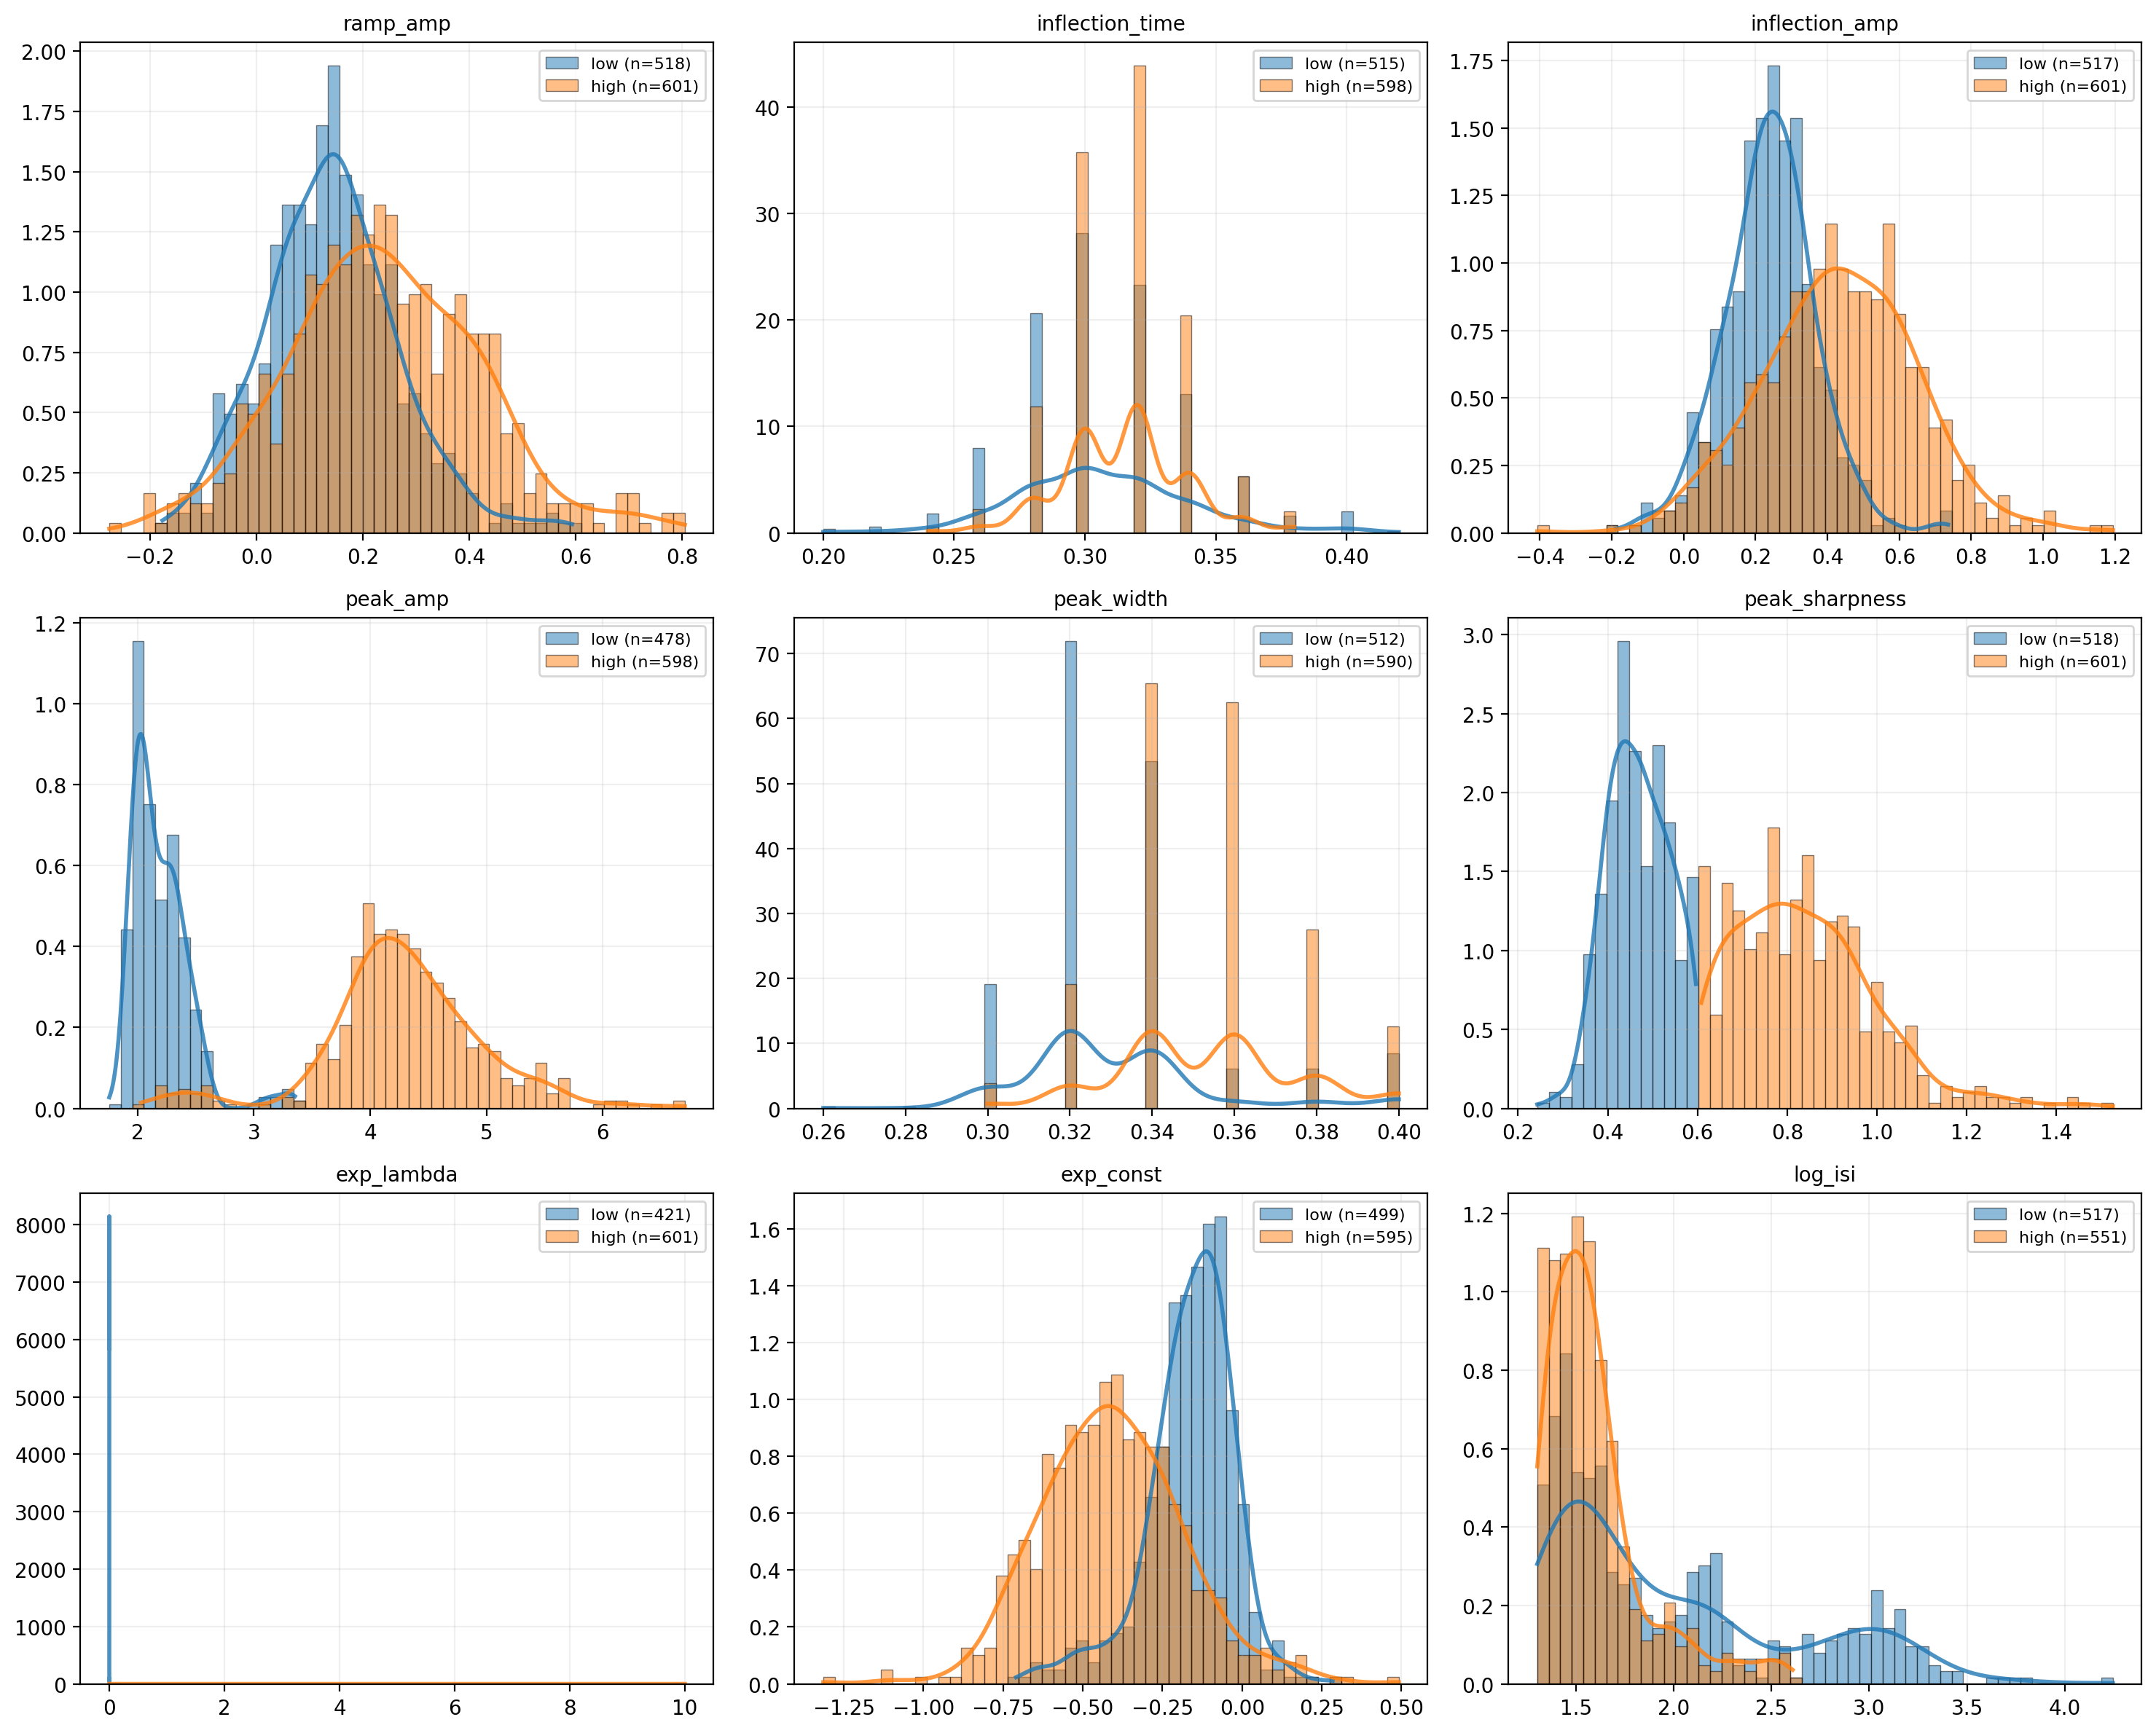


→ 5. Statistical analysis for: peak_sharpness
----------------------------------------

Test: Mann-Whitney U (nonparametric)
Number of groups: 2
P-value: 0.000000
Significance: ***
η² effect size: 0.684
Interpretation: Very Large


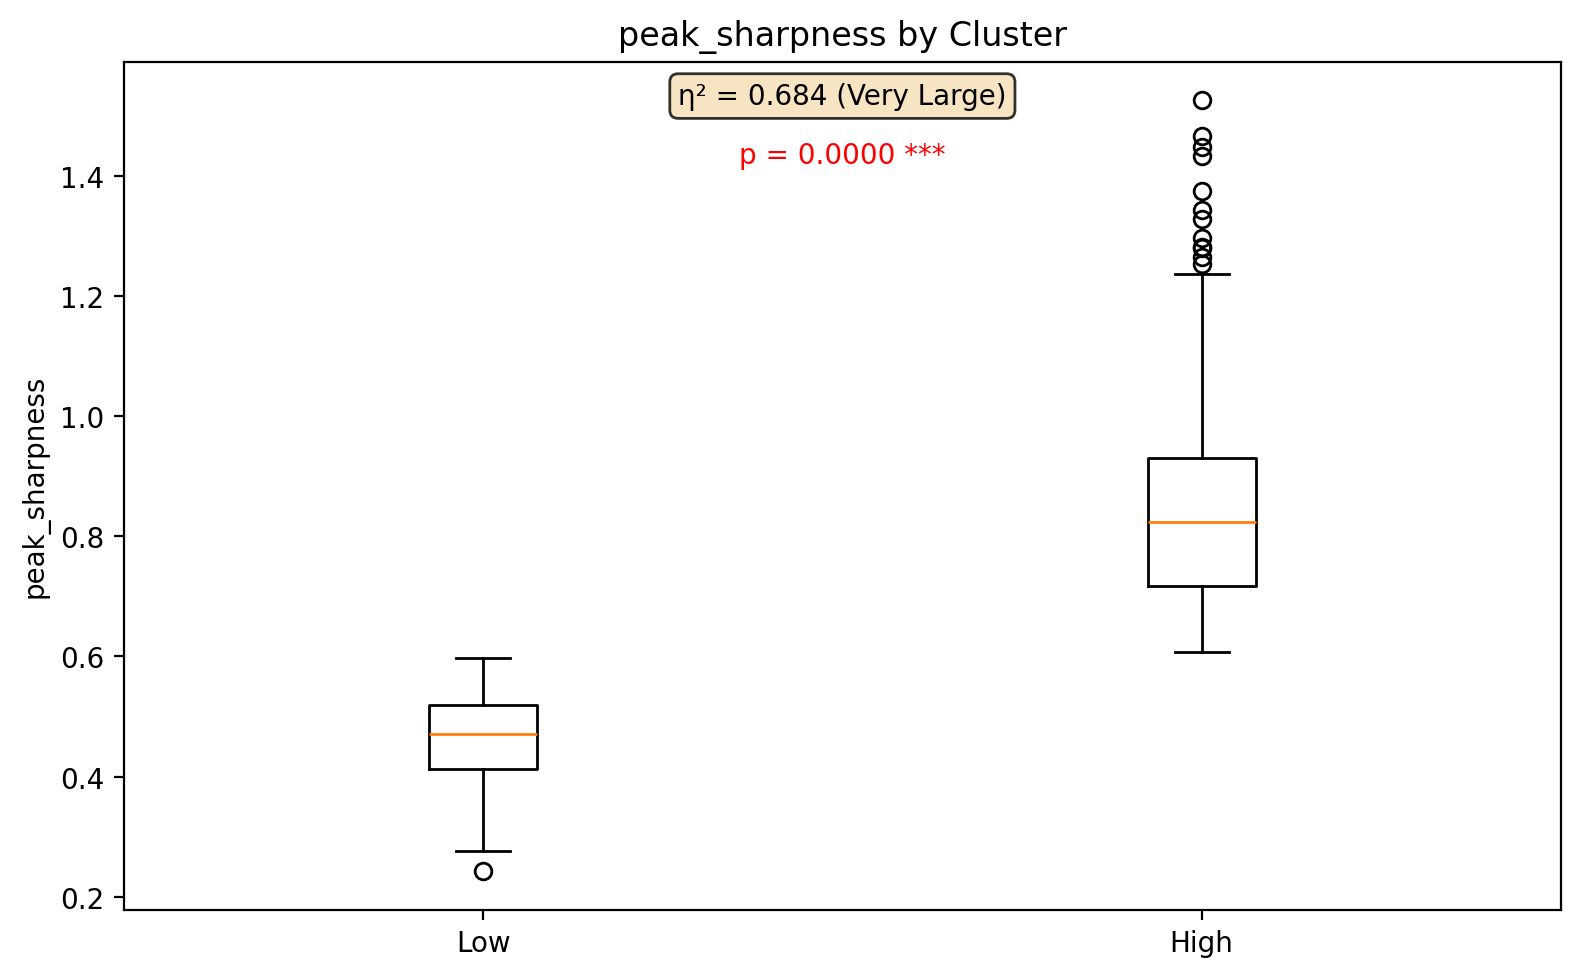


===== REPORT COMPLETE =====


===== CLUSTER REPORT: exp_lambda_cluster =====
Found 2 clusters: ['high', 'low']

→ Determining cluster colors and labels...
  Using existing cluster labels: ['high', 'low']
  Groups: ('low', 'high')
  Group names: ('Low', 'High')

→ 1. Plotting spike waveforms by cluster

→ 1.5 Average waveforms with visual RMSE


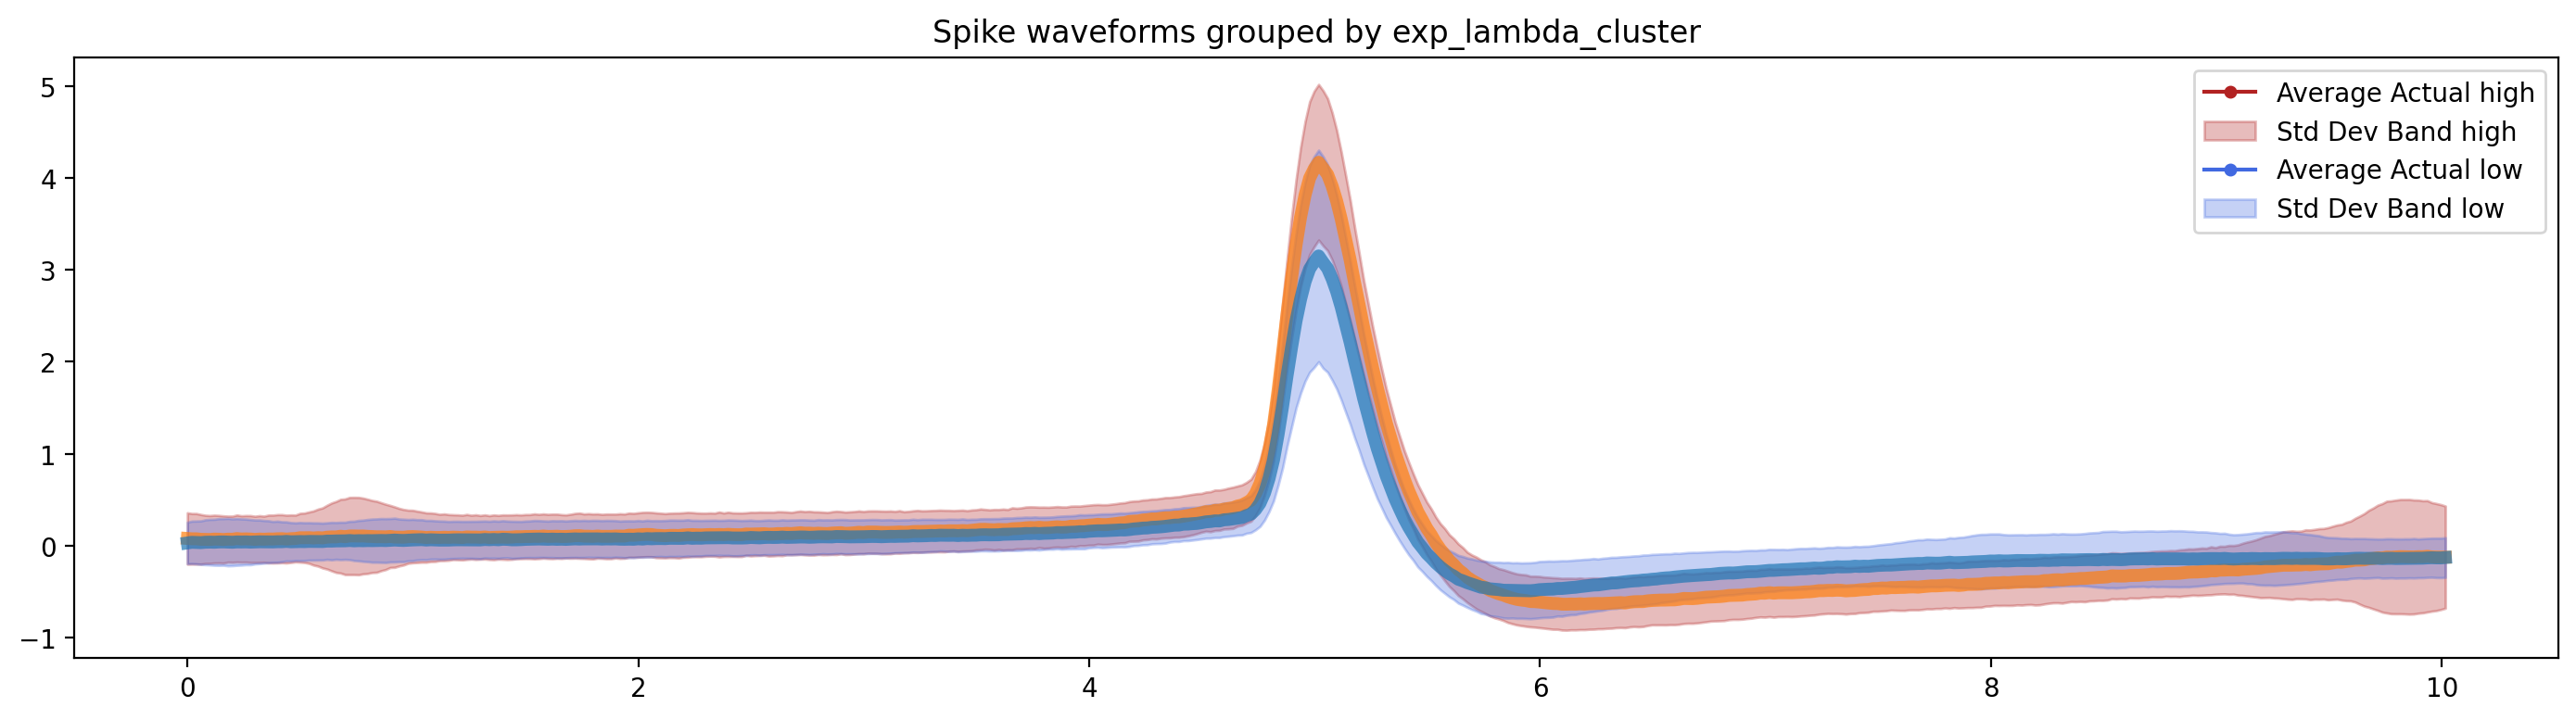

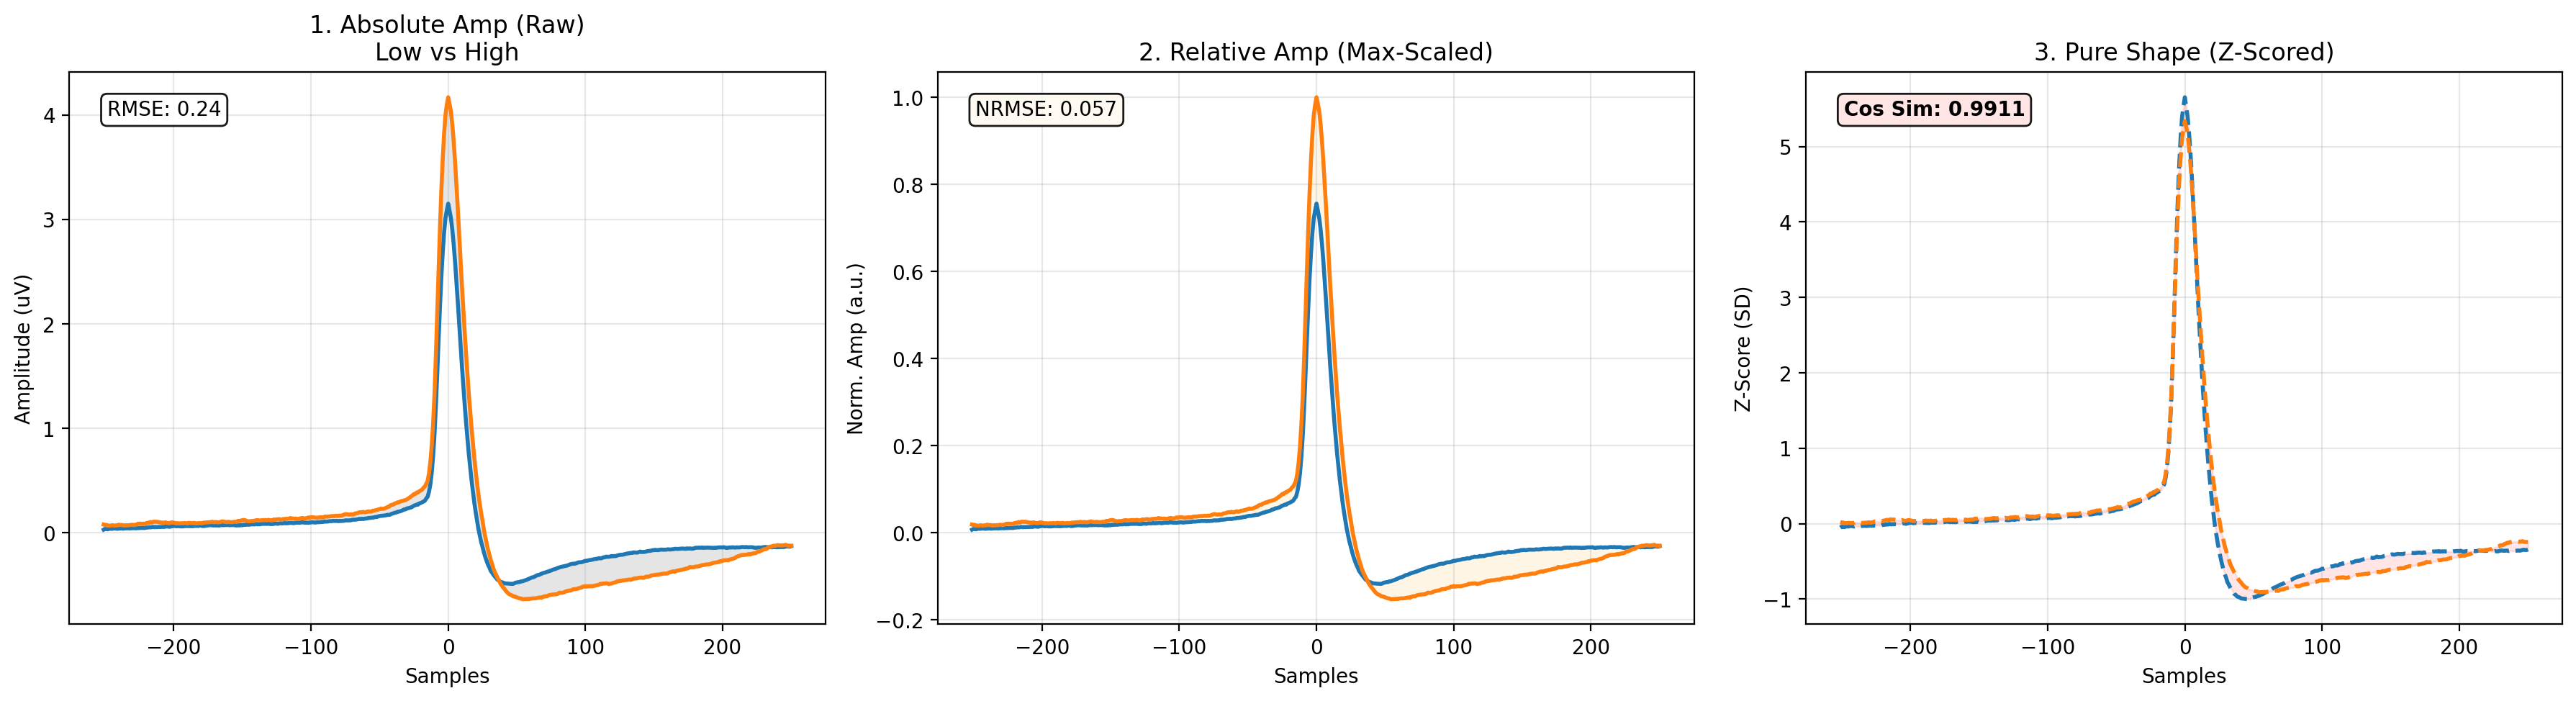


→ 2. Plotting cluster proportions over time


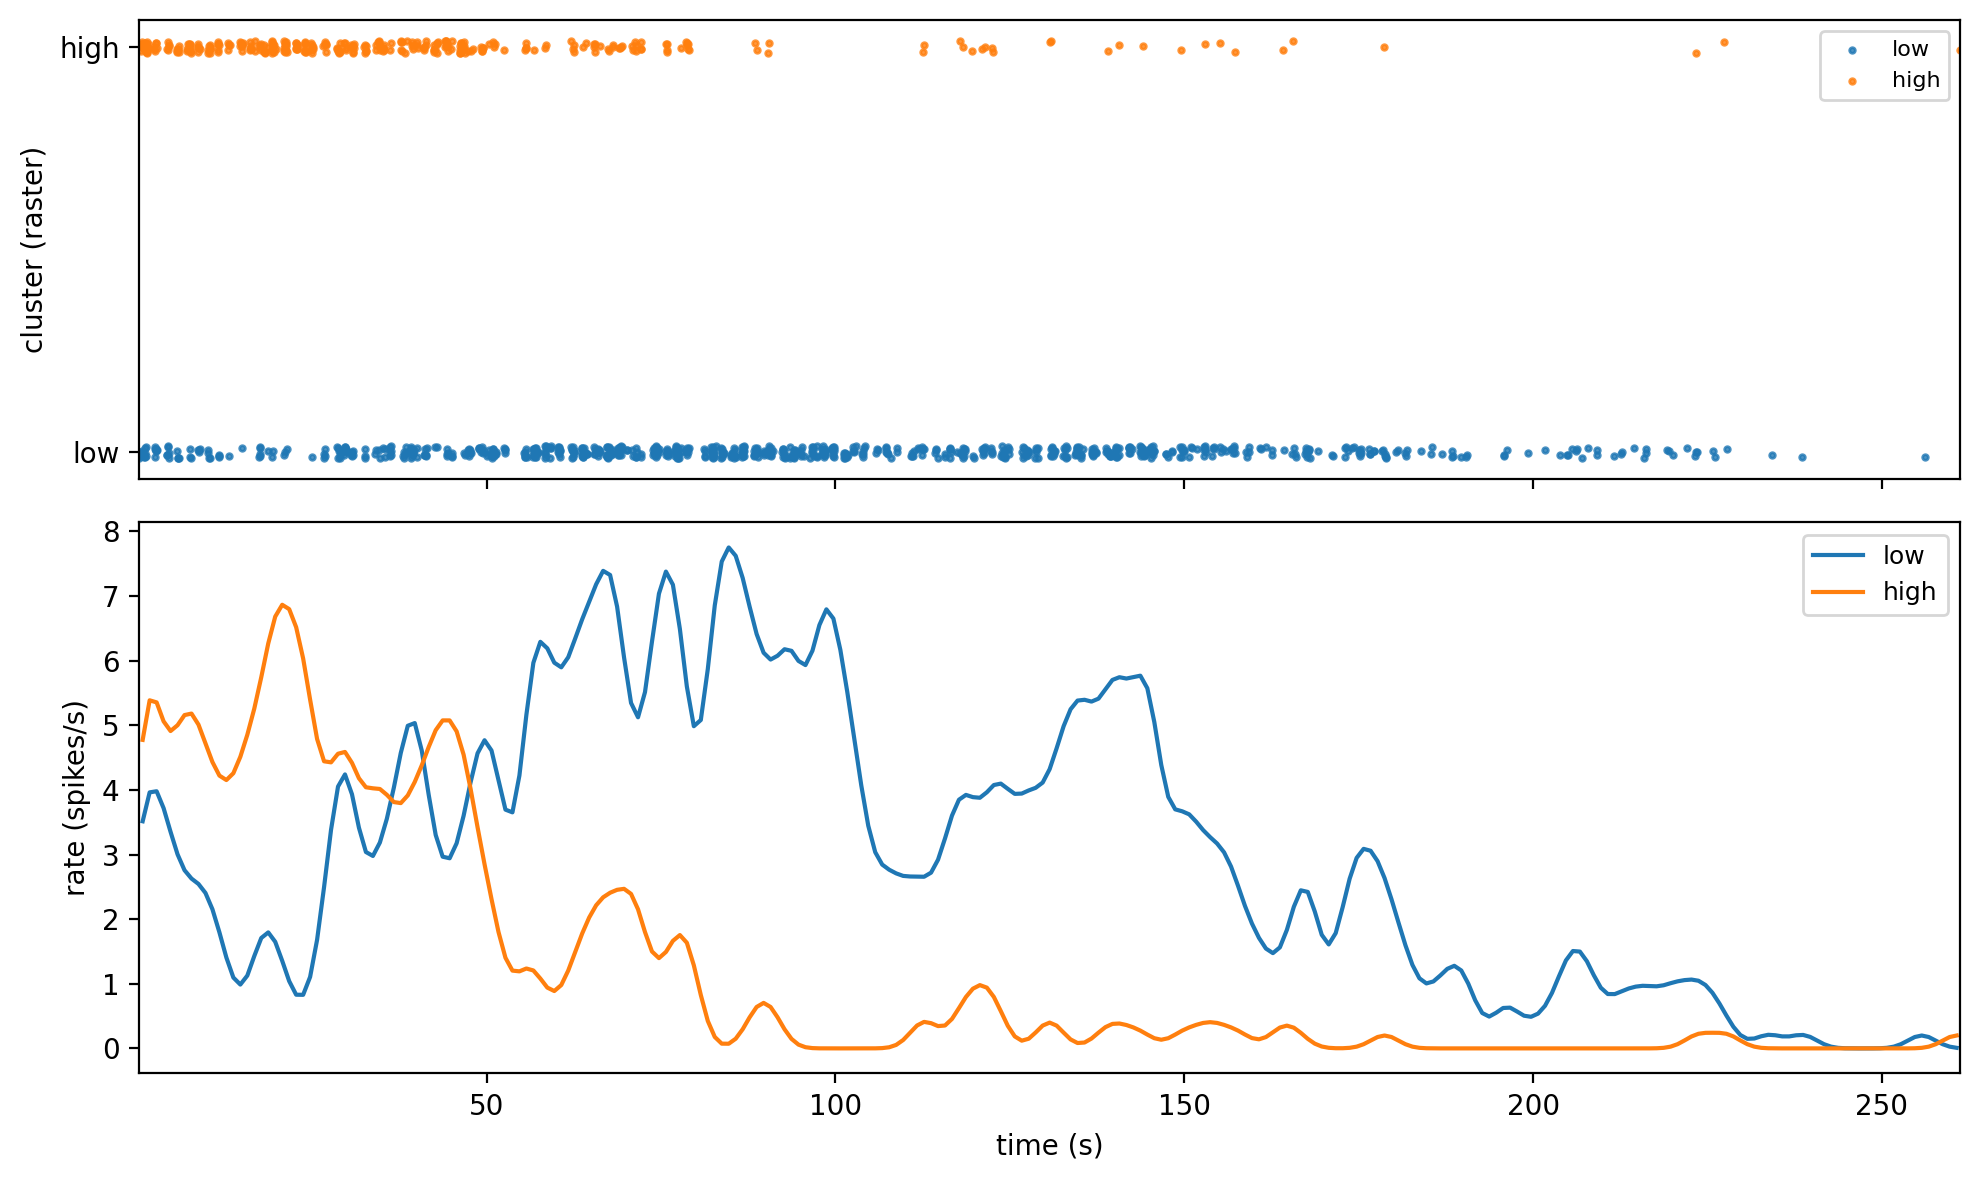


→ 3. Computing cluster transition matrix


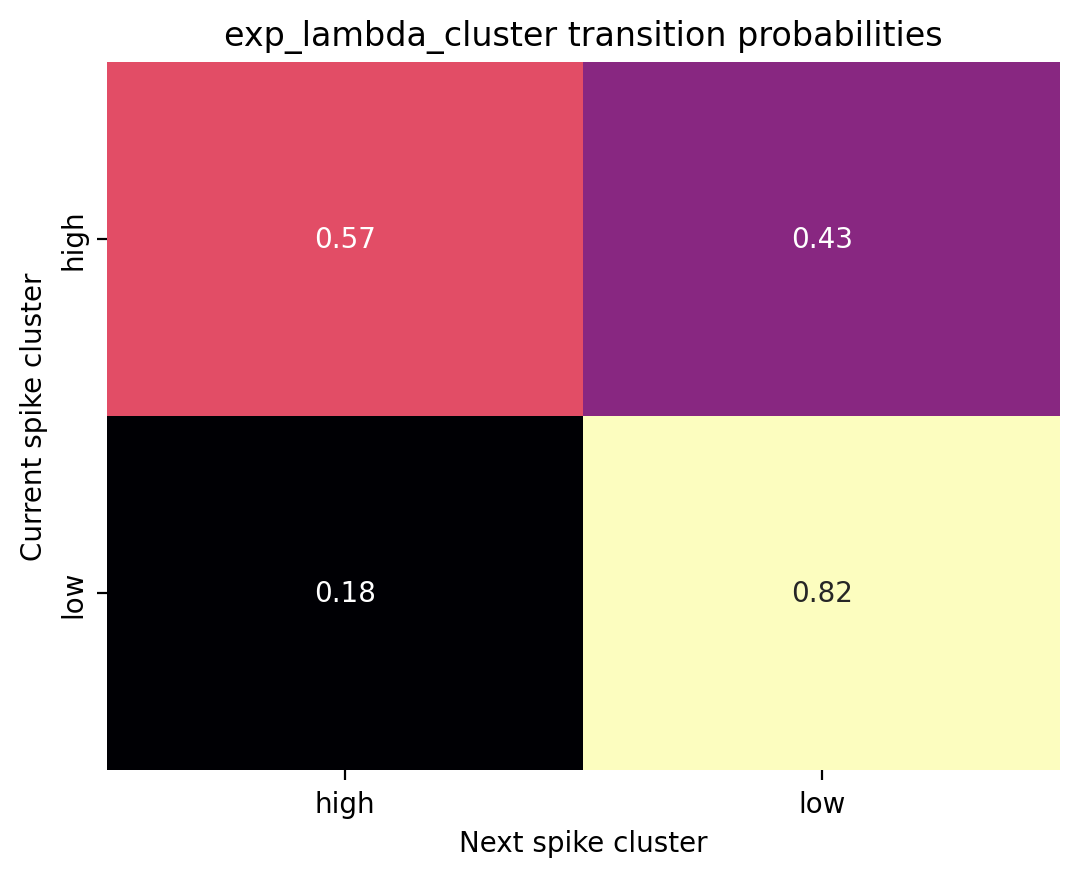


→ 4. Visualizing feature distributions by cluster


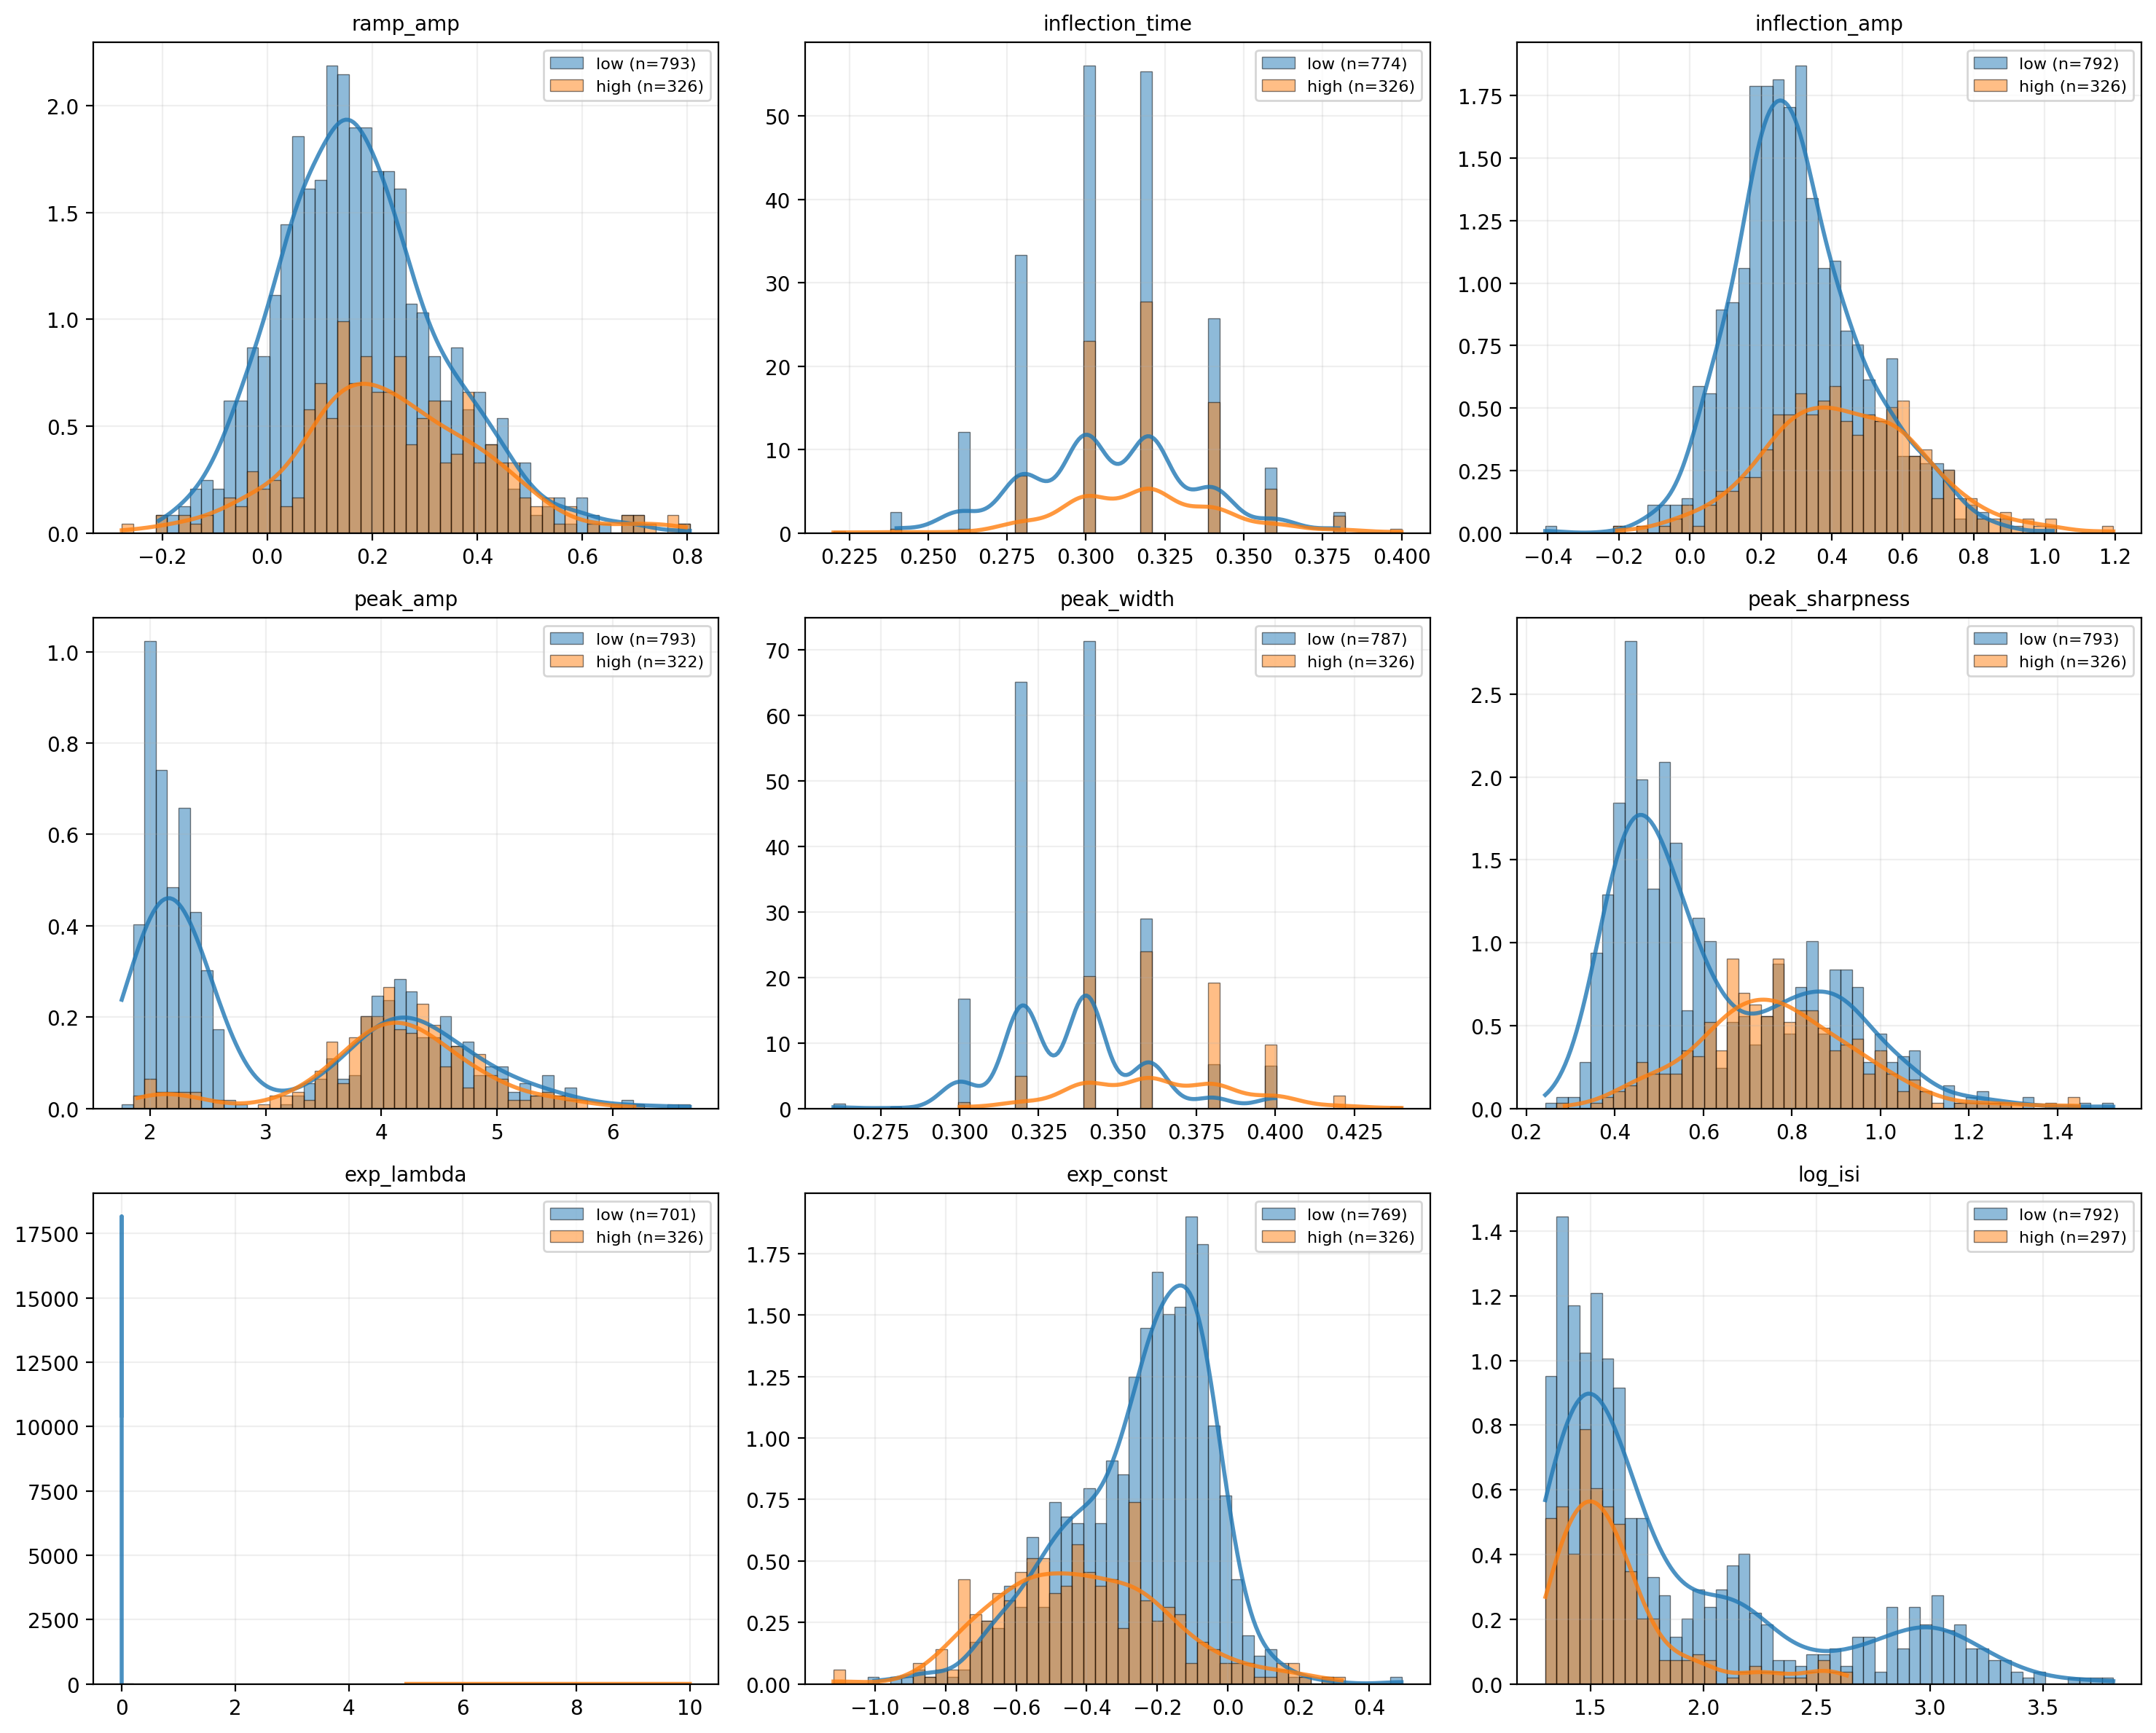


→ 5. Statistical analysis for: exp_lambda
----------------------------------------

Test: Mann-Whitney U (nonparametric)
Number of groups: 2
P-value: 0.000000
Significance: ***
η² effect size: 0.939
Interpretation: Very Large


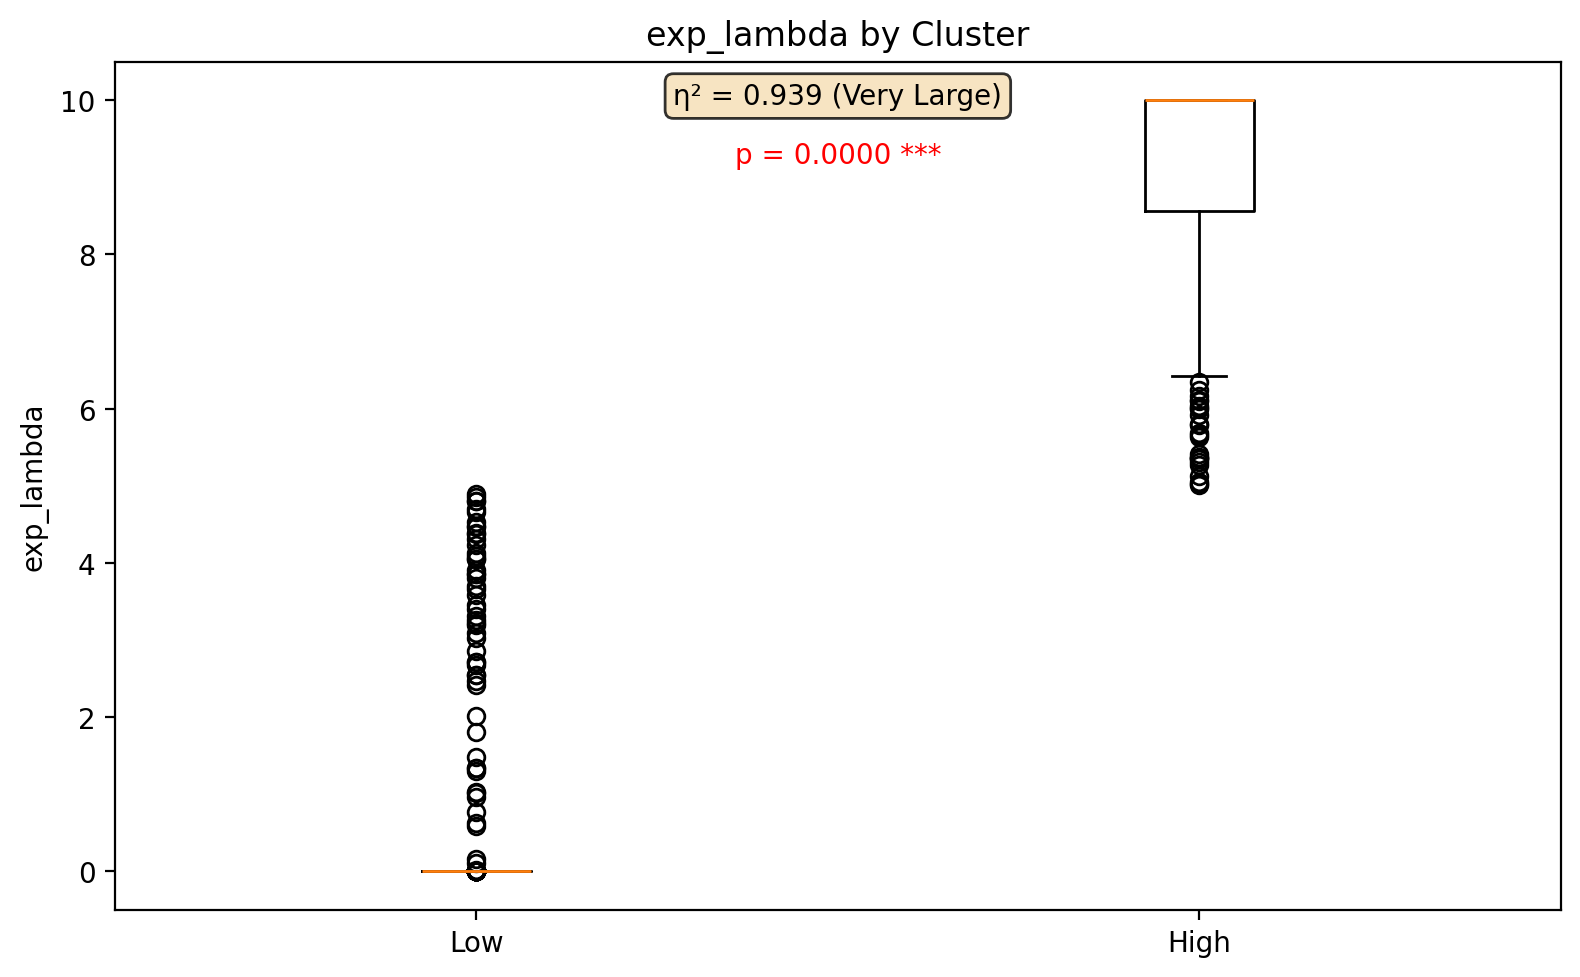


===== REPORT COMPLETE =====


===== CLUSTER REPORT: log_isi_cluster =====
Found 3 clusters: ['high', 'low', 'mid']

→ Determining cluster colors and labels...
  Using existing cluster labels: ['high', 'low', 'mid']
  Groups: ('low', 'mid', 'high')
  Group names: ('Low', 'Mid', 'High')

→ 1. Plotting spike waveforms by cluster

→ 1.5 Average waveforms with visual RMSE


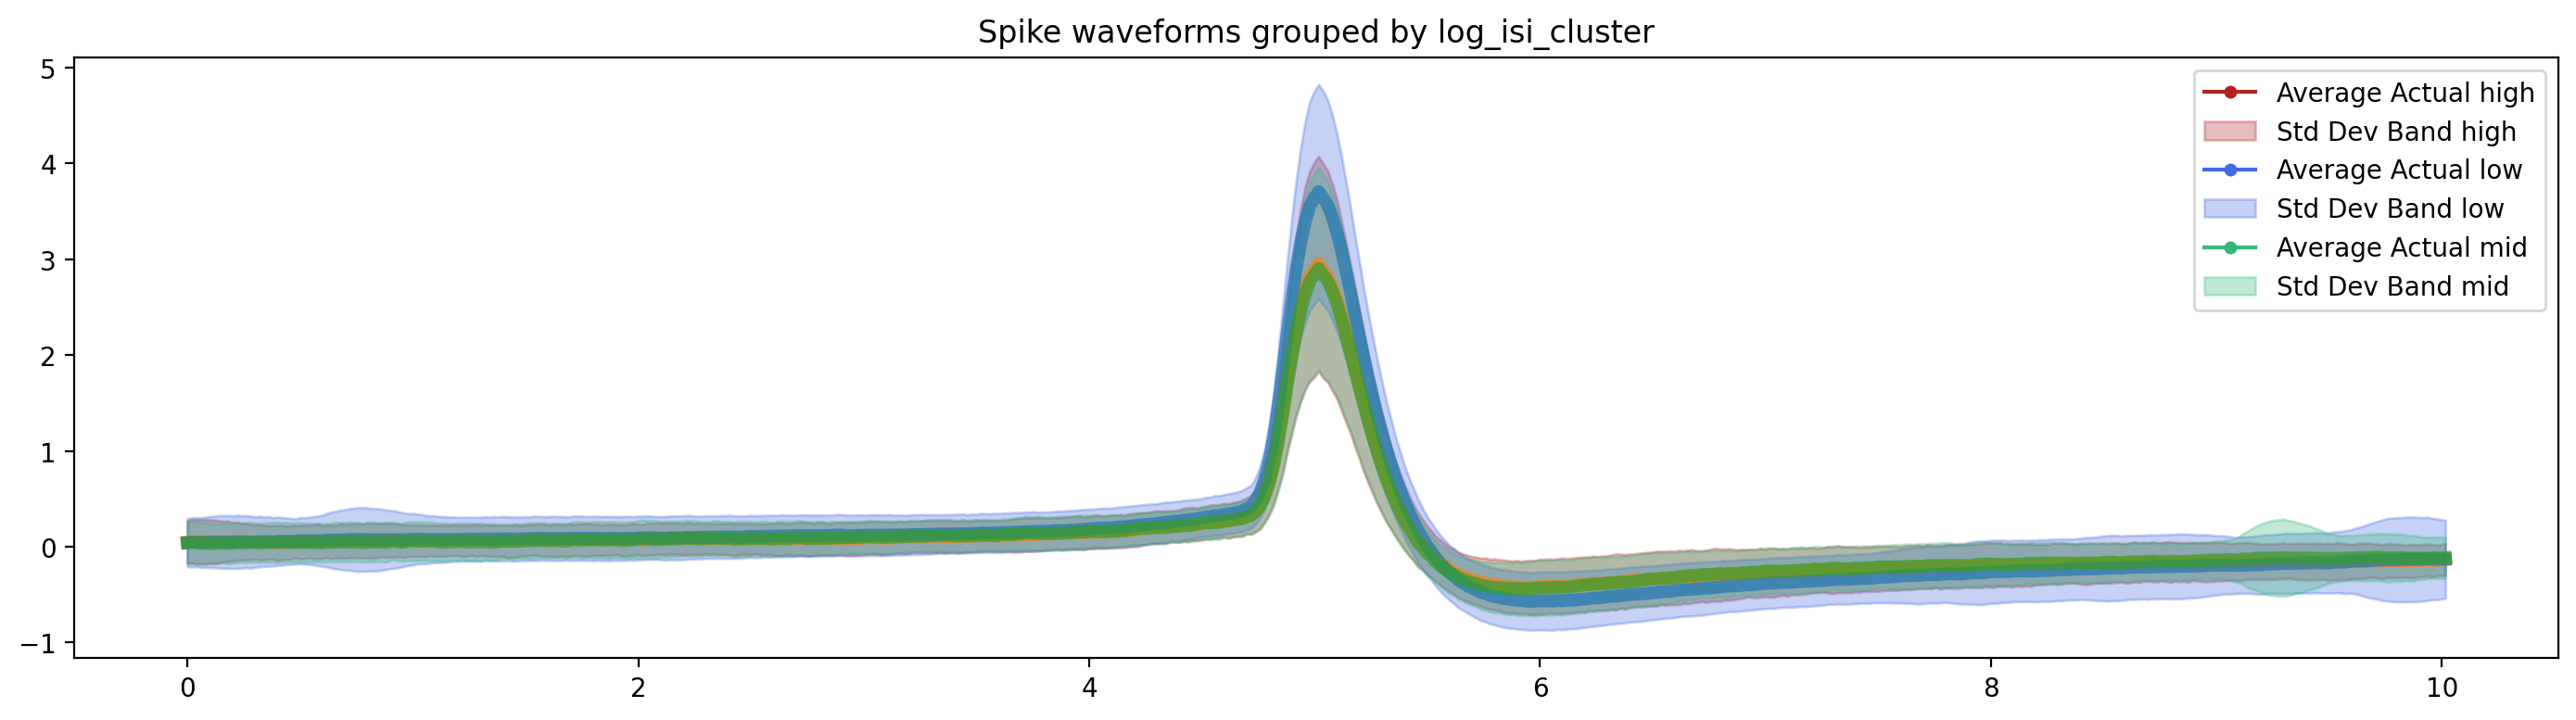

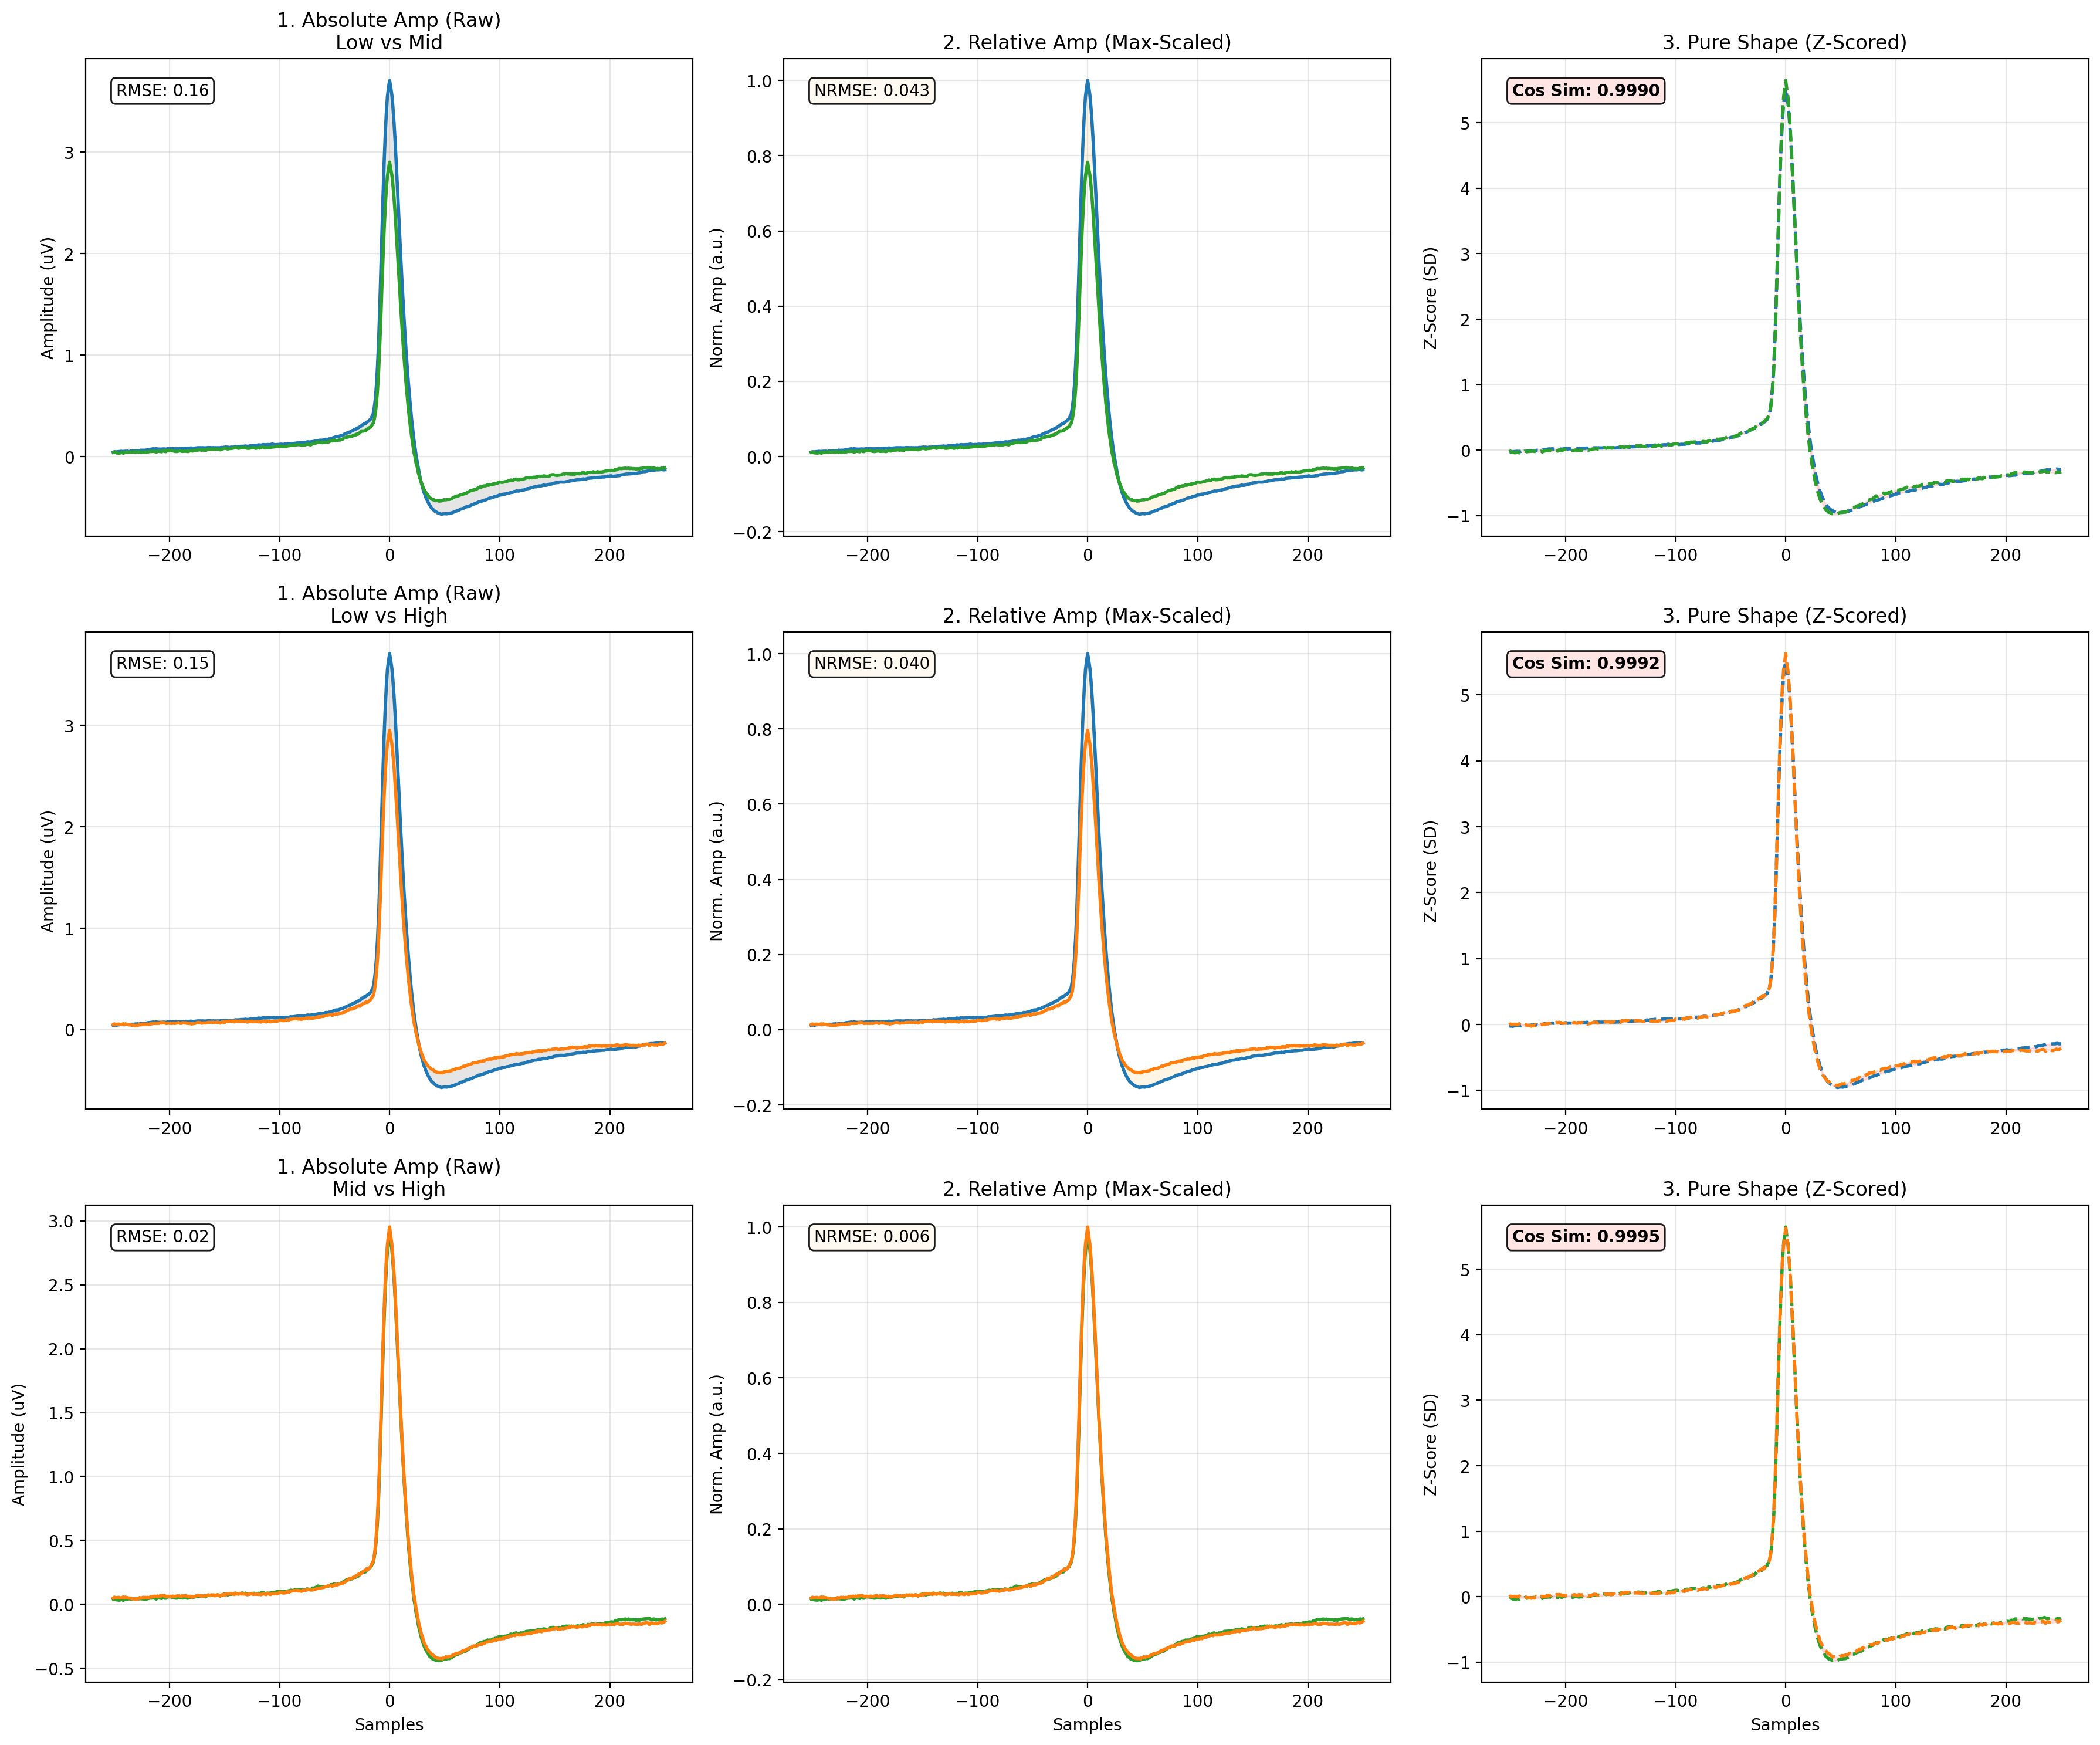


→ 2. Plotting cluster proportions over time


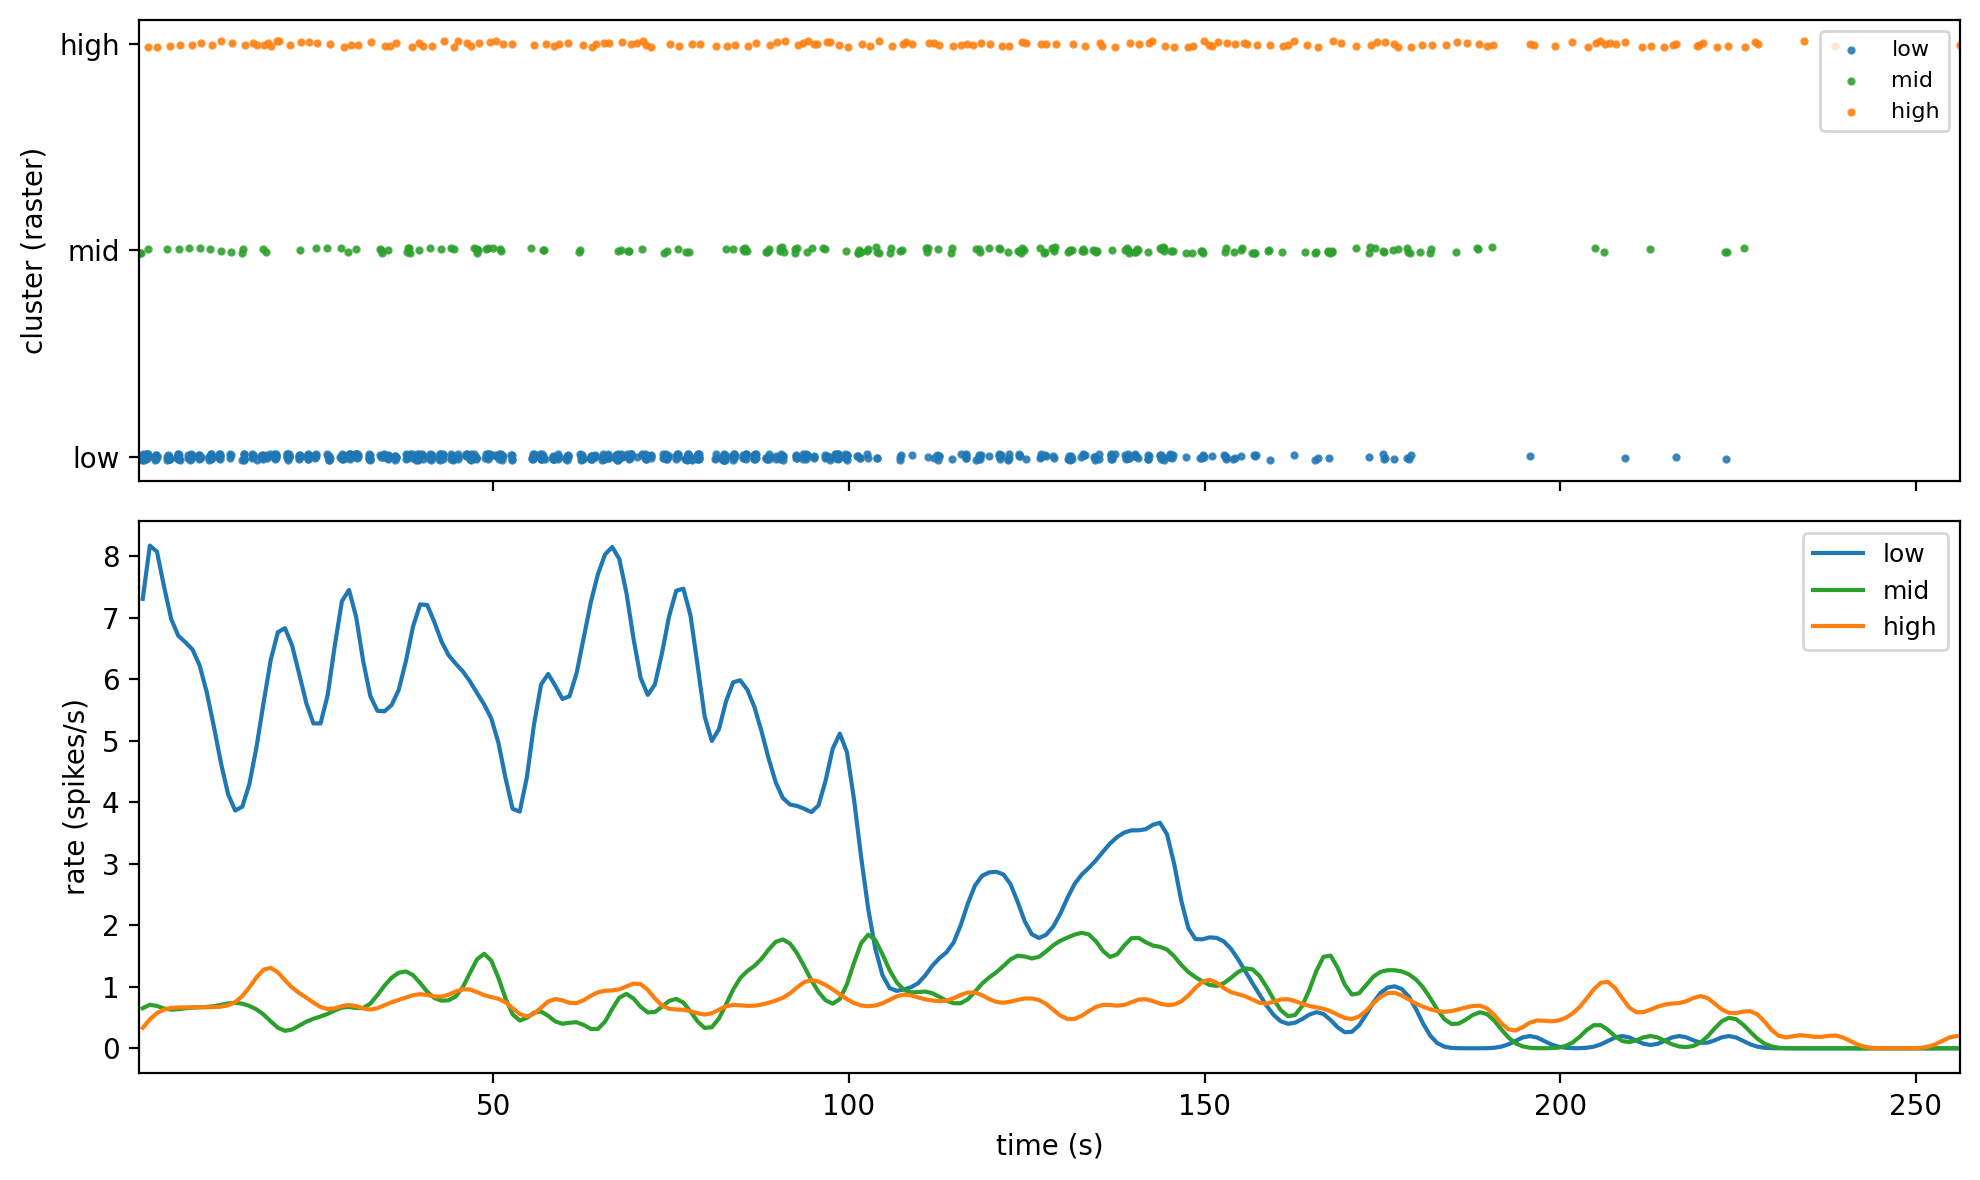


→ 3. Computing cluster transition matrix


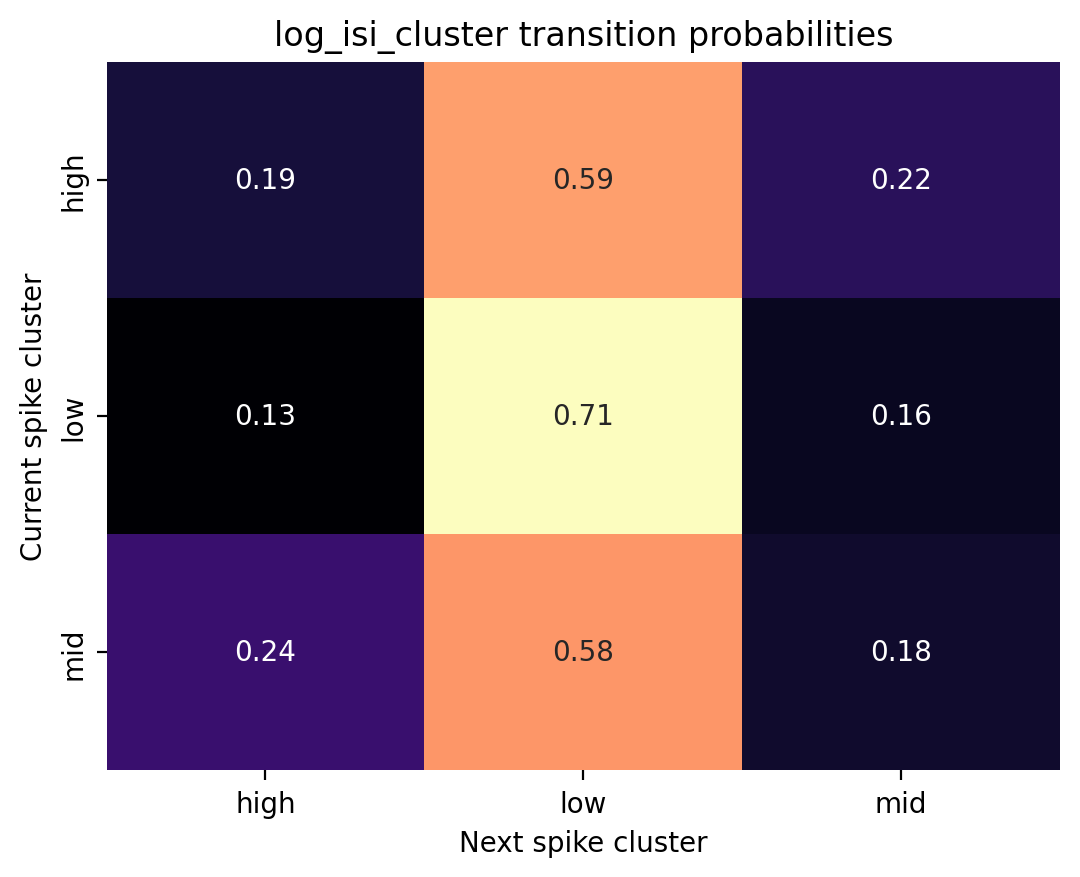


→ 4. Visualizing feature distributions by cluster


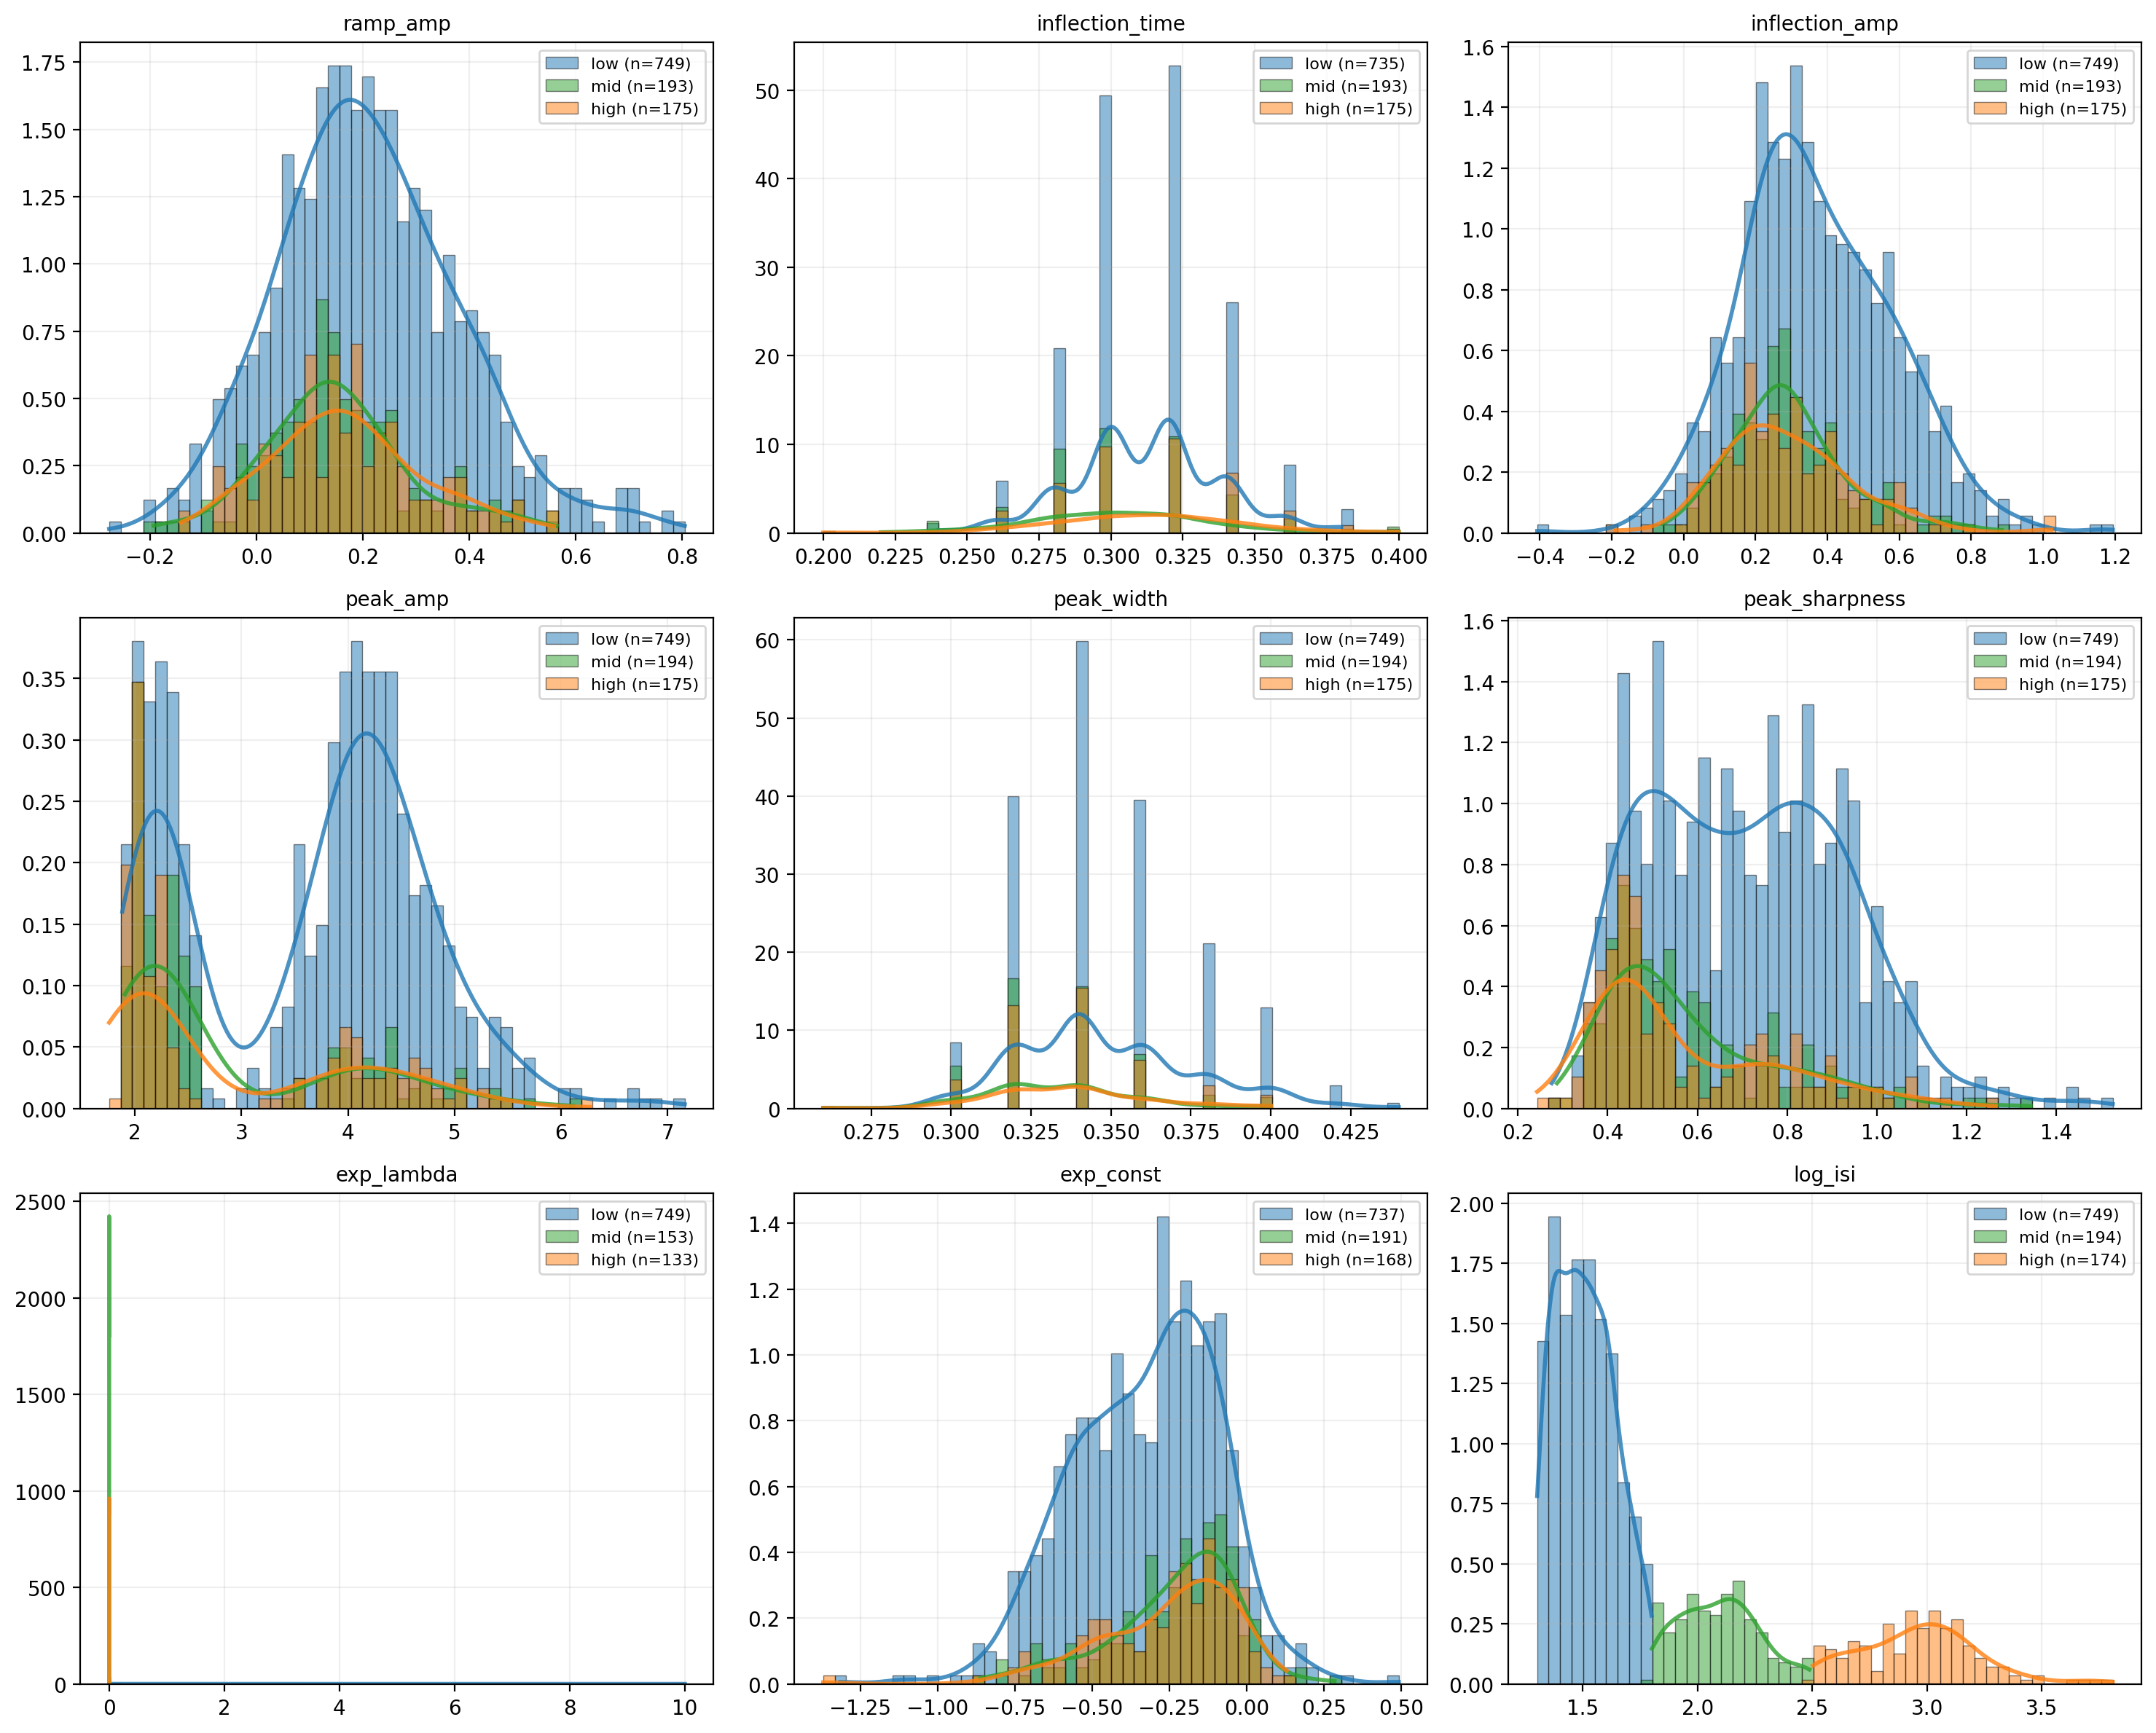


→ 5. Statistical analysis for: log_isi
----------------------------------------

Test: Kruskal-Wallis (nonparametric)
Number of groups: 3
P-value: 0.000000
Significance: ***
η² effect size: 0.690
Interpretation: Very Large


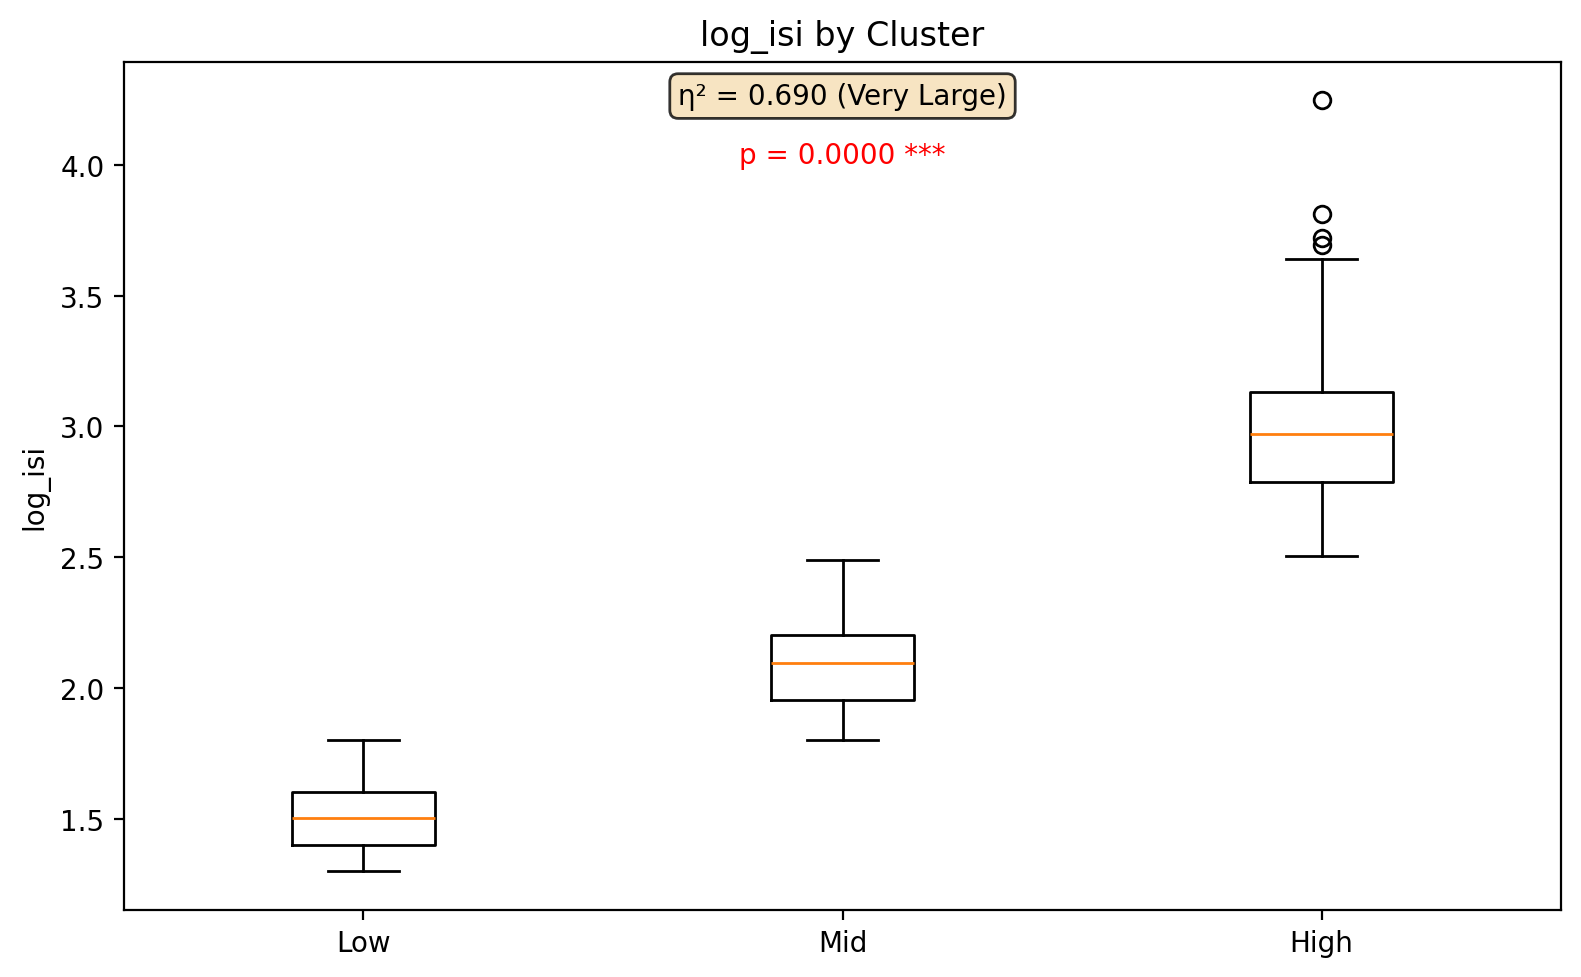


===== REPORT COMPLETE =====



In [18]:
all_reports = []

# Filter columns first to ensure the index is continuous
cluster_cols = [c for c in df_features_clust.columns if c.endswith("_cluster")]

for i, col in enumerate(cluster_cols):
    # Pass 'i' as the cluster_group_id
    row_df = plot_full_cluster_report(df_features_clust, sp, col, cluster_group_id=i)
    all_reports.append(row_df)

# Final Master DataFrame
master_report_df = pd.concat(all_reports, ignore_index=True)

In [19]:
master_report_df

,cluster_group_id,feature_clustered,groups,nRMSE,cos_sim,temporal_rho,temporal_p
0,0,peak_amp,Low-High,0.097334,0.990675,-0.836876,1.362049e-294
1,1,peak_sharpness,Low-High,0.089531,0.994335,-0.696692,2.509393e-163
2,2,exp_lambda,Low-High,0.057151,0.991093,-0.513388,2.884357e-76
3,3,log_isi,Low-Mid,0.042822,0.998956,0.349626,1.720911e-33
4,3,log_isi,Low-High,0.039851,0.999172,0.349626,1.720911e-33
5,3,log_isi,Mid-High,0.006494,0.999520,0.349626,1.720911e-33


In [20]:
#export cluster info df 

with open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/cluster_pickles/c1_df_clusters.pkl', 'wb') as file:
    pickle.dump(master_report_df, file)